# Sanity check: empirical privacy vs. formal differential privacy

This notebook isolates the privacy mechanism from the larger multivariate example and studies it in one dimension.

The goal is **not** to show that the original prototype is useless. Its reconstruction results can still be informative. The goal is to separate two different questions:

1. **Does the perturbation make a particular reconstruction attack difficult?**
2. **Does the mechanism satisfy a formal differential-privacy guarantee?**

Those are not the same property.

The notebook is parameterized so the same analysis can be rerun for different datasets, sample sizes, bounds, privacy parameters, and neighboring-subject changes.

For now we use **fixed-size replacement adjacency**: neighboring datasets have the same number of subjects and differ in exactly one subject.

## 1. Configuration

Change the values in the next cell to define a new experiment.

Two dataset modes are supported:

- `"manual"`: use the values supplied in `manual_values`;
- `"normal"`: simulate `n` observations from a normal distribution and clip them to the public bounds.

The default configuration reproduces the original toy example.

Important parameters:

- `lower_bound`, `upper_bound`: public clipping/domain bounds used for global sensitivity;
- `neighbor_index`: which subject is changed to create the neighboring dataset;
- `neighbor_replacement`: replacement value for that subject;
- `epsilon`, `delta`: privacy parameters used by the formal Gaussian comparison;
- `n_draws`: number of repeated randomized releases used to approximate each output distribution.

The formal Gaussian mechanisms below use an analytic calibration, so $\epsilon$ only needs to be strictly positive.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

from IPython.display import Markdown, display

CONFIG = {
    # Dataset construction
    "dataset_mode": "manual",      # "manual" or "normal"
    "manual_values": [10, 11, 12, 13, 14],
    "n": 20,                       # used only when dataset_mode == "normal"
    "population_mean": 12.0,       # used only for simulated data
    "population_sd": 2.0,          # used only for simulated data

    # Public domain / clipping bounds
    "lower_bound": 0.0,
    "upper_bound": 20.0,

    # Neighbor construction
    "neighbor_index": -1,
    "neighbor_replacement": 20.0,

    # Privacy parameters
    "epsilon": 1.0,
    "delta": 1e-5,

    # Prototype settings
    "prototype_noise_multiplier": 1.0,
    "rejection_noise_multiplier": 2.0,
    "max_attempts": 10_000,

    # Monte Carlo settings
    "n_draws": 50_000,
    "seed": 42,

    # Smaller number of draws for optional parameter sweeps
    "sweep_draws": 5_000,
    "reconstruction_draws": 2_000,
}

## 2. Construct a dataset and one neighboring dataset

The released statistic is the sample mean,

$$
f(D)=\bar{x}.
$$

A neighboring dataset $D'$ is constructed by replacing exactly one subject value.

This is the practical DP comparison:

> Would the randomized release look substantially different if one subject's value were different?

The attacker does not need to search all possible datasets. A particular attacker may have narrowed the possibilities down to one neighboring pair, so the mechanism should not make that pair too easy to distinguish.

In [2]:
def validate_config(config):
    if config["dataset_mode"] not in {"manual", "normal"}:
        raise ValueError("dataset_mode must be 'manual' or 'normal'.")

    lower = float(config["lower_bound"])
    upper = float(config["upper_bound"])

    if not lower < upper:
        raise ValueError("lower_bound must be smaller than upper_bound.")

    if not (float(config["epsilon"]) > 0):
        raise ValueError("epsilon must be strictly positive.")

    if not (0 < float(config["delta"]) < 1):
        raise ValueError("delta must lie strictly between 0 and 1.")

    replacement = float(config["neighbor_replacement"])
    if not lower <= replacement <= upper:
        raise ValueError(
            "neighbor_replacement must lie within the public bounds."
        )


def build_dataset(config):
    validate_config(config)

    lower = float(config["lower_bound"])
    upper = float(config["upper_bound"])

    if config["dataset_mode"] == "manual":
        data = np.asarray(config["manual_values"], dtype=float)
        if data.ndim != 1 or len(data) < 2:
            raise ValueError("manual_values must contain at least two values.")

        if np.any(data < lower) or np.any(data > upper):
            raise ValueError(
                "All manual values must lie within the public bounds."
            )

    else:
        rng = np.random.default_rng(config["seed"])
        data = rng.normal(
            loc=float(config["population_mean"]),
            scale=float(config["population_sd"]),
            size=int(config["n"]),
        )
        data = np.clip(data, lower, upper)

    return data


def make_neighbor(data, index, replacement_value):
    neighbor = np.asarray(data, dtype=float).copy()
    index = int(index)

    # Resolve negative indices explicitly for readability.
    if index < 0:
        index = len(neighbor) + index

    if index < 0 or index >= len(neighbor):
        raise IndexError("neighbor_index is outside the dataset.")

    neighbor[index] = float(replacement_value)
    return neighbor, index


D = build_dataset(CONFIG)

D_neighbor, changed_index = make_neighbor(
    D,
    CONFIG["neighbor_index"],
    CONFIG["neighbor_replacement"],
)

print("Dataset mode:", CONFIG["dataset_mode"])
print("n:", len(D))
print("Changed subject index:", changed_index)
print("Original value:", D[changed_index])
print("Replacement value:", D_neighbor[changed_index])

print("\nD:")
print(D)

print("\nD_neighbor:")
print(D_neighbor)

print("\nMeans:")
print("D mean:        ", np.mean(D))
print("Neighbor mean: ", np.mean(D_neighbor))
print("Absolute mean change:", abs(np.mean(D) - np.mean(D_neighbor)))

Dataset mode: manual
n: 5
Changed subject index: 4
Original value: 14.0
Replacement value: 20.0

D:
[10. 11. 12. 13. 14.]

D_neighbor:
[10. 11. 12. 13. 20.]

Means:
D mean:         12.0
Neighbor mean:  13.2
Absolute mean change: 1.1999999999999993


### Practical interpretation

$D$ and $D'$ are not two datasets we intend to publish. They represent two possible private worlds.

A randomized mechanism does not always return the same value. If it were run repeatedly on the same dataset, it would produce a **distribution of possible released means**.

An attacker who knows the mechanism can compare

$$
P(Y=y \mid D)
$$

with

$$
P(Y=y \mid D').
$$

If an observed release is much more plausible under one dataset than the other, the release provides evidence about which private world generated it.

## 3. Dataset-specific leave-one-out quantities

For each subject, remove that subject and recompute the mean. This gives

$$
\bar{x}_{-1},\bar{x}_{-2},\ldots,\bar{x}_{-n}.
$$

Two different quantities are calculated.

### LOO scale

$$
s_{\mathrm{LOO}}
=
\operatorname{SD}
\left(
\bar{x}_{-1},\ldots,\bar{x}_{-n}
\right).
$$

This measures the **typical spread** of the leave-one-out means.

### Empirical LOO sensitivity

$$
\Delta_{\mathrm{LOO}}(D)
=
\max_i
\left|
\bar{x}_D-\bar{x}_{-i}
\right|.
$$

This measures the **largest observed influence** among subjects actually present in this dataset.

Both quantities depend on the private data, so both can change between neighboring datasets.

In [3]:
def empirical_loo_sensitivity(data):
    data = np.asarray(data, dtype=float)
    true_mean = np.mean(data)

    loo_means = np.array([
        np.mean(np.delete(data, i))
        for i in range(len(data))
    ])

    sensitivity = np.max(
        np.abs(loo_means - true_mean)
    )

    loo_scale = np.std(loo_means)

    return true_mean, loo_means, sensitivity, loo_scale


mean_D, loo_D, sens_D, scale_D = empirical_loo_sensitivity(D)
mean_N, loo_N, sens_N, scale_N = empirical_loo_sensitivity(D_neighbor)

print("=== Dataset D ===")
print("Mean:", mean_D)
print("LOO means:", loo_D)
print("Empirical LOO sensitivity:", sens_D)
print("LOO scale:", scale_D)

print("\n=== Neighboring dataset ===")
print("Mean:", mean_N)
print("LOO means:", loo_N)
print("Empirical LOO sensitivity:", sens_N)
print("LOO scale:", scale_N)

=== Dataset D ===
Mean: 12.0
LOO means: [12.5  12.25 12.   11.75 11.5 ]
Empirical LOO sensitivity: 0.5
LOO scale: 0.3535533905932738

=== Neighboring dataset ===
Mean: 13.2
LOO means: [14.   13.75 13.5  13.25 11.5 ]
Empirical LOO sensitivity: 1.6999999999999993
LOO scale: 0.8860022573334675


### What the LOO results mean

The important comparison is not only whether the two means differ.

Check whether the following also differ between $D$ and $D'$:

- `LOO scale`;
- `empirical LOO sensitivity`.

If they do, then a mechanism that calibrates its randomization directly from these quantities changes its own behavior when one private subject changes.

That does **not** mean dataset-adaptive privacy mechanisms are impossible. It means that this adaptation itself has to be included in the privacy analysis.

## 4. Global sensitivity for the bounded mean

The public bounds are

$$
L \leq x_i \leq U.
$$

For a fixed-size mean under **replacement adjacency**, replacing one subject can change the mean by at most

$$
\Delta_{\mathrm{global}}
=
\frac{U-L}{n}.
$$

This is a worst-case bound. Unlike empirical LOO sensitivity, it does not depend on which valid private dataset is currently being analyzed.

If the adjacency definition later changes to add/remove adjacency, this sensitivity calculation must also be changed.

In [4]:
lower_bound = float(CONFIG["lower_bound"])
upper_bound = float(CONFIG["upper_bound"])
n = len(D)

global_sensitivity = (
    upper_bound - lower_bound
) / n

print("Public bounds:", (lower_bound, upper_bound))
print("n:", n)
print("Global sensitivity:", global_sensitivity)

Public bounds: (0.0, 20.0)
n: 5
Global sensitivity: 4.0


## 5. Three mechanisms to compare

We now compare three different constructions.

### A. Dataset-dependent Gaussian diagnostic

The Gaussian width is determined from the private dataset's LOO scale:

$$
\sigma_D
=
c\frac{s_{\mathrm{LOO}}(D)}{\epsilon},
$$

where $c$ is `prototype_noise_multiplier`.

This is a diagnostic used to isolate the effect of a dataset-dependent noise width. It is not claimed to be a formal DP mechanism.

### B. Prototype rejection mechanism

The Gaussian width is based on the LOO scale, and a draw is accepted only if

$$
|z|
\geq
\Delta_{\mathrm{LOO}}(D).
$$

This mirrors the sensitivity-rejection idea from the original prototype in one dimension.

### C. Gaussian DP comparison

For the formal comparison we use the classic sufficient calibration

$$
\sigma
=
\frac{
\Delta_{\mathrm{global}}
\sqrt{2\ln(1.25/\delta)}
}{
\epsilon
}.
$$

The same noise scale is used for every valid neighboring dataset with the same public bounds and sample size.

In [5]:
def dataset_dependent_gaussian_sd(
    loo_scale,
    epsilon,
    multiplier=1.0,
):
    return multiplier * loo_scale / epsilon


def classic_gaussian_dp_sd(
    global_sensitivity,
    epsilon,
    delta,
):
    """
    Classical sufficient Gaussian calibration.

    Kept for comparison only. Formal mechanisms later in the notebook
    use analytic_gaussian_dp_sd().
    """
    return (
        global_sensitivity
        * np.sqrt(2 * np.log(1.25 / delta))
        / epsilon
    )


def gaussian_pair_delta(
    mean_difference,
    sigma,
    epsilon,
):
    """
    Exact hockey-stick divergence delta for two equal-variance Gaussian
    output distributions whose means differ by `mean_difference`.
    """
    d = abs(float(mean_difference))
    sigma = float(sigma)
    epsilon = float(epsilon)

    if d == 0:
        return 0.0

    if sigma <= 0:
        raise ValueError("sigma must be positive when mean_difference > 0.")

    alpha = d / sigma

    delta_value = (
        norm.cdf(
            alpha / 2
            - epsilon / alpha
        )
        - np.exp(epsilon)
        * norm.cdf(
            -alpha / 2
            - epsilon / alpha
        )
    )

    return max(0.0, float(delta_value))


def analytic_gaussian_dp_sd(
    global_sensitivity,
    epsilon,
    delta,
    *,
    rtol=1e-12,
    max_iter=200,
):
    """
    Find the smallest Gaussian SD whose exact hockey-stick divergence
    is at most the requested delta for the worst allowed mean shift.
    """
    sensitivity = float(global_sensitivity)
    epsilon = float(epsilon)
    delta = float(delta)

    if sensitivity < 0:
        raise ValueError("Sensitivity must be non-negative.")

    if sensitivity == 0:
        return 0.0

    if epsilon <= 0:
        raise ValueError("epsilon must be strictly positive.")

    if not (0 < delta < 1):
        raise ValueError("delta must lie strictly between 0 and 1.")

    lower_sigma = 0.0
    upper_sigma = max(sensitivity, 1e-12)

    # Find an upper bracket that is sufficiently private.
    while (
        gaussian_pair_delta(
            sensitivity,
            upper_sigma,
            epsilon,
        )
        > delta
    ):
        upper_sigma *= 2.0

    # Bisect to the smallest sufficient sigma.
    for _ in range(max_iter):
        mid_sigma = (
            lower_sigma + upper_sigma
        ) / 2.0

        current_delta = gaussian_pair_delta(
            sensitivity,
            mid_sigma,
            epsilon,
        )

        if current_delta > delta:
            lower_sigma = mid_sigma
        else:
            upper_sigma = mid_sigma

        if (
            upper_sigma - lower_sigma
            <= rtol * max(1.0, upper_sigma)
        ):
            break

    return upper_sigma


def sample_gaussian_outputs(
    mean,
    noise_sd,
    n_draws,
    rng,
):
    noise = rng.normal(
        loc=0.0,
        scale=noise_sd,
        size=n_draws,
    )
    return mean + noise


def sample_rejection_outputs(
    mean,
    loo_scale,
    sensitivity,
    n_draws,
    rng,
    *,
    multiplier=2.0,
    max_attempts=10_000,
):
    noise_sd = multiplier * loo_scale

    outputs = np.full(
        n_draws,
        np.nan,
        dtype=float,
    )

    remaining = np.arange(n_draws)

    # Each loop represents one additional rejection-sampling attempt
    # for every release that has not yet found a valid draw.
    for _ in range(max_attempts):
        if len(remaining) == 0:
            break

        noise = rng.normal(
            loc=0.0,
            scale=noise_sd,
            size=len(remaining),
        )

        accepted = np.abs(noise) >= sensitivity

        outputs[remaining[accepted]] = (
            mean + noise[accepted]
        )

        remaining = remaining[~accepted]

    return outputs

## 6. Simulate repeated releases

Each array below contains many **possible releases of the same statistic**.

They are not new participants and not new datasets.

For example, `prototype_D` answers:

> If the dataset-dependent Gaussian mechanism were repeatedly run on the same dataset $D$, what released means could occur?

The repeated draws approximate the mechanism's output distribution.

### Classical versus analytic calibration

The notebook keeps the classical Gaussian calibration function for reference, but the formal mechanisms below use the analytic calibration.

For the same sensitivity and the same target $(\epsilon,\delta)$:

- the classical formula is sufficient but conservative;
- the analytic calibration solves the Gaussian privacy condition more tightly;
- therefore the analytic $\sigma$ should be less than or equal to the classical $\sigma$.

This improves utility **without weakening the requested privacy guarantee**.

Earlier versions of this notebook used the classical sufficient calibration

$$
\sigma
=
\frac{
\Delta\sqrt{2\ln(1.25/\delta)}
}{
\epsilon
}.
$$

That formula is easy to understand, but it is conservative: it can add more noise than necessary.

We already have the exact Gaussian privacy calculation for two equal-variance neighboring Gaussian output distributions. Therefore we can invert that calculation numerically.

For a target

$$
(\epsilon,\delta)
$$

and sensitivity

$$
\Delta,
$$

we choose the smallest $\sigma$ such that

$$
\delta_{\mathrm{Gaussian}}
(\epsilon,\Delta,\sigma)
\leq
\delta_{\mathrm{target}}.
$$

This is the idea behind the analytic Gaussian mechanism: calibrate the Gaussian distribution directly rather than using the older tail bound.

The result is still a formal Gaussian DP mechanism, but with better utility.

In [ ]:
classic_gaussian_sd = classic_gaussian_dp_sd(
    global_sensitivity,
    float(CONFIG["epsilon"]),
    float(CONFIG["delta"]),
)

analytic_gaussian_sd = analytic_gaussian_dp_sd(
    global_sensitivity,
    float(CONFIG["epsilon"]),
    float(CONFIG["delta"]),
)

print("Classic Gaussian SD: ", classic_gaussian_sd)
print("Analytic Gaussian SD:", analytic_gaussian_sd)
print(
    "Relative noise reduction:",
    1 - analytic_gaussian_sd / classic_gaussian_sd,
    "%"
)

Classic Gaussian SD:  19.379221050421556
Analytic Gaussian SD: 14.922526539274259
Relative noise reduction: 0.22997284047442923


In [7]:
epsilon = float(CONFIG["epsilon"])
delta = float(CONFIG["delta"])
n_draws = int(CONFIG["n_draws"])
seed = int(CONFIG["seed"])

prototype_sd_D = dataset_dependent_gaussian_sd(
    scale_D,
    epsilon,
    CONFIG["prototype_noise_multiplier"],
)

prototype_sd_N = dataset_dependent_gaussian_sd(
    scale_N,
    epsilon,
    CONFIG["prototype_noise_multiplier"],
)

gaussian_sd = analytic_gaussian_dp_sd(
    global_sensitivity,
    epsilon,
    delta,
)

# Separate reproducible RNG streams for each mechanism / dataset.
seed_sequence = np.random.SeedSequence(seed)
child_seeds = seed_sequence.spawn(6)
rngs = [np.random.default_rng(s) for s in child_seeds]

prototype_D = sample_gaussian_outputs(
    mean_D,
    prototype_sd_D,
    n_draws,
    rngs[0],
)

prototype_neighbor = sample_gaussian_outputs(
    mean_N,
    prototype_sd_N,
    n_draws,
    rngs[1],
)

formal_D = sample_gaussian_outputs(
    mean_D,
    gaussian_sd,
    n_draws,
    rngs[2],
)

formal_neighbor = sample_gaussian_outputs(
    mean_N,
    gaussian_sd,
    n_draws,
    rngs[3],
)

prototype_reject_D = sample_rejection_outputs(
    mean_D,
    scale_D,
    sens_D,
    n_draws,
    rngs[4],
    multiplier=CONFIG["rejection_noise_multiplier"],
    max_attempts=CONFIG["max_attempts"],
)

prototype_reject_neighbor = sample_rejection_outputs(
    mean_N,
    scale_N,
    sens_N,
    n_draws,
    rngs[5],
    multiplier=CONFIG["rejection_noise_multiplier"],
    max_attempts=CONFIG["max_attempts"],
)

print("Dataset-dependent Gaussian SD, D:       ", prototype_sd_D)
print("Dataset-dependent Gaussian SD, neighbor:", prototype_sd_N)
print("Formal Gaussian DP SD:                  ", gaussian_sd)

print("\nRejection failures, D:",
      np.isnan(prototype_reject_D).sum())
print("Rejection failures, neighbor:",
      np.isnan(prototype_reject_neighbor).sum())

Dataset-dependent Gaussian SD, D:        0.3535533905932738
Dataset-dependent Gaussian SD, neighbor: 0.8860022573334675
Formal Gaussian DP SD:                   14.922526539274259

Rejection failures, D: 0
Rejection failures, neighbor: 0


### Interpreting repeated-release means and SDs

For each mechanism, the simulated mean should remain close to the true statistic because the added Gaussian noise is centered at zero.

The more informative quantity is the **spread of the output distribution**.

For the dataset-dependent mechanism, compare the SD under $D$ with the SD under $D'$. If they differ, changing one private subject changed the randomization distribution itself.

For the formal Gaussian comparison, both neighboring datasets use the same noise SD.

In [8]:
summary = pd.DataFrame([
    {
        "mechanism": "dataset-dependent Gaussian",
        "dataset": "D",
        "true_mean": mean_D,
        "release_mean": np.nanmean(prototype_D),
        "release_sd": np.nanstd(prototype_D),
    },
    {
        "mechanism": "dataset-dependent Gaussian",
        "dataset": "D_neighbor",
        "true_mean": mean_N,
        "release_mean": np.nanmean(prototype_neighbor),
        "release_sd": np.nanstd(prototype_neighbor),
    },
    {
        "mechanism": "formal Gaussian DP",
        "dataset": "D",
        "true_mean": mean_D,
        "release_mean": np.nanmean(formal_D),
        "release_sd": np.nanstd(formal_D),
    },
    {
        "mechanism": "formal Gaussian DP",
        "dataset": "D_neighbor",
        "true_mean": mean_N,
        "release_mean": np.nanmean(formal_neighbor),
        "release_sd": np.nanstd(formal_neighbor),
    },
    {
        "mechanism": "prototype rejection",
        "dataset": "D",
        "true_mean": mean_D,
        "release_mean": np.nanmean(prototype_reject_D),
        "release_sd": np.nanstd(prototype_reject_D),
    },
    {
        "mechanism": "prototype rejection",
        "dataset": "D_neighbor",
        "true_mean": mean_N,
        "release_mean": np.nanmean(prototype_reject_neighbor),
        "release_sd": np.nanstd(prototype_reject_neighbor),
    },
])

summary

,mechanism,dataset,true_mean,release_mean,release_sd
0,dataset-dependent Gaussian,D,12.0,11.998177,0.353891
1,dataset-dependent Gaussian,D_neighbor,13.2,13.199695,0.884833
2,formal Gaussian DP,D,12.0,12.008866,15.011437
3,formal Gaussian DP,D_neighbor,13.2,13.171597,14.905012
4,prototype rejection,D,12.0,11.998627,0.980305
5,prototype rejection,D_neighbor,13.2,13.206607,2.761873


## 7. Output distributions

The next plots visualize the same neighboring-dataset question for the current configuration.

### Dataset-dependent Gaussian

The two distributions can differ in:

1. center, because the true means differ;
2. width, because the LOO scale is recalculated from each private dataset.

Narrow distributions give good numerical utility, but can make the two neighboring worlds easier to distinguish.

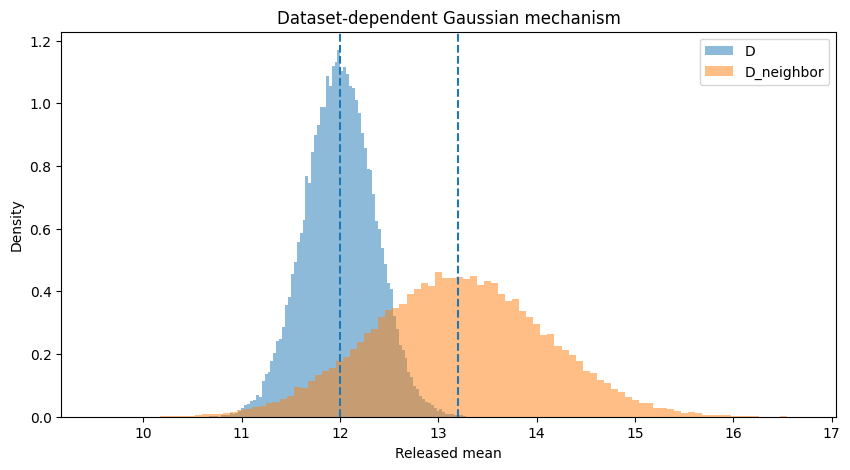

In [9]:
plt.figure(figsize=(10, 5))

plt.hist(
    prototype_D,
    bins=100,
    density=True,
    alpha=0.5,
    label="D",
)

plt.hist(
    prototype_neighbor,
    bins=100,
    density=True,
    alpha=0.5,
    label="D_neighbor",
)

plt.axvline(mean_D, linestyle="--")
plt.axvline(mean_N, linestyle="--")

plt.xlabel("Released mean")
plt.ylabel("Density")
plt.title("Dataset-dependent Gaussian mechanism")
plt.legend()
plt.show()

### Formal Gaussian comparison

Both neighboring datasets use the same noise standard deviation.

If the global sensitivity is large relative to the difference between the neighboring means, the two distributions overlap strongly. This improves privacy but can reduce utility.

For a bounded mean,

$$
\Delta_{\mathrm{global}}
=
\frac{U-L}{n},
$$

so increasing sample size reduces sensitivity.

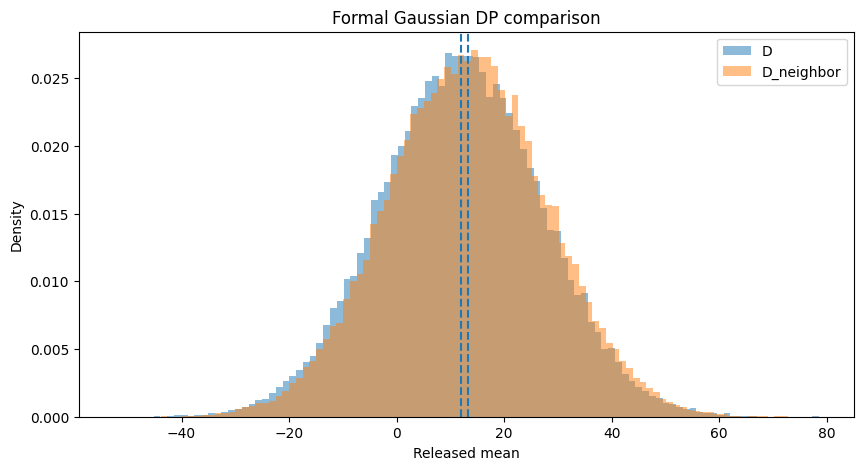

In [10]:
plt.figure(figsize=(10, 5))

plt.hist(
    formal_D,
    bins=100,
    density=True,
    alpha=0.5,
    label="D",
)

plt.hist(
    formal_neighbor,
    bins=100,
    density=True,
    alpha=0.5,
    label="D_neighbor",
)

plt.axvline(mean_D, linestyle="--")
plt.axvline(mean_N, linestyle="--")

plt.xlabel("Released mean")
plt.ylabel("Density")
plt.title("Formal Gaussian DP comparison")
plt.legend()
plt.show()

### Prototype sensitivity rejection

The rejection rule forbids noise satisfying

$$
|z| < \Delta_{\mathrm{LOO}}.
$$

Since

$$
Y=\bar{x}+z,
$$

the forbidden output interval for a dataset is

$$
\left(
\bar{x}-\Delta_{\mathrm{LOO}},
\;
\bar{x}+\Delta_{\mathrm{LOO}}
\right).
$$

The interval is calculated below from the **current data**, so no hard-coded toy values remain.

Forbidden interval under D: (np.float64(11.5), np.float64(12.5))
Forbidden interval under D_neighbor: (np.float64(11.5), np.float64(14.899999999999999))


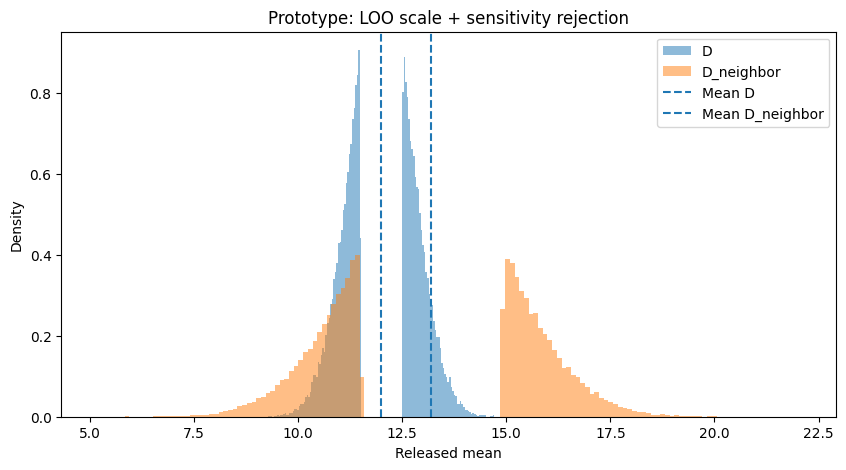

In [11]:
gap_D = (
    mean_D - sens_D,
    mean_D + sens_D,
)

gap_N = (
    mean_N - sens_N,
    mean_N + sens_N,
)

print("Forbidden interval under D:", gap_D)
print("Forbidden interval under D_neighbor:", gap_N)

plt.figure(figsize=(10, 5))

plt.hist(
    prototype_reject_D,
    bins=150,
    density=True,
    alpha=0.5,
    label="D",
)

plt.hist(
    prototype_reject_neighbor,
    bins=150,
    density=True,
    alpha=0.5,
    label="D_neighbor",
)

plt.axvline(mean_D, linestyle="--", label="Mean D")
plt.axvline(mean_N, linestyle="--", label="Mean D_neighbor")

plt.xlabel("Released mean")
plt.ylabel("Density")
plt.title("Prototype: LOO scale + sensitivity rejection")
plt.legend()
plt.show()

## 8. Quantify dataset-exclusive rejection outputs

A useful diagnostic is to ask how often an output generated under one dataset is **impossible** under the other dataset's rejection rule.

For a released value $y$, the rejection mechanism regards it as possible under a dataset only when

$$
|y-\bar{x}|
\geq
\Delta_{\mathrm{LOO}}.
$$

This is not yet the full differential-privacy calculation, but it directly exposes the support mismatch created by dataset-dependent rejection thresholds.

In [12]:
def rejection_output_is_possible(
    output,
    mean,
    sensitivity,
):
    return np.abs(output - mean) >= sensitivity


valid_D = prototype_reject_D[
    np.isfinite(prototype_reject_D)
]

valid_N = prototype_reject_neighbor[
    np.isfinite(prototype_reject_neighbor)
]

D_impossible_under_neighbor = (
    ~rejection_output_is_possible(
        valid_D,
        mean_N,
        sens_N,
    )
)

N_impossible_under_D = (
    ~rejection_output_is_possible(
        valid_N,
        mean_D,
        sens_D,
    )
)

exclusive_prob_D = np.mean(
    D_impossible_under_neighbor
)

exclusive_prob_N = np.mean(
    N_impossible_under_D
)

print(
    "P(output from D is impossible under D_neighbor):",
    exclusive_prob_D,
)

print(
    "P(output from D_neighbor is impossible under D):",
    exclusive_prob_N,
)

P(output from D is impossible under D_neighbor): 0.49944
P(output from D_neighbor is impossible under D): 0.0


### Interpretation of the exclusive-output probabilities

If this probability is substantial, the rejection mechanism can produce outputs that rule out one neighboring dataset completely under the known mechanism.

That may still coexist with strong resistance to a reconstruction attack.

The point of this notebook is precisely to keep these two claims separate:

- **reconstruction resistance** asks whether an individual value can be recovered accurately;
- **differential privacy** asks whether neighboring private worlds remain sufficiently hard to distinguish from the released output.

## 9. Reusable experiment runner

The helper below packages the same analysis into one function.

This makes it possible to run many scenarios without rewriting the notebook.

It returns summary quantities rather than plots, including:

- empirical LOO sensitivities;
- LOO scales;
- global sensitivity;
- noise scales;
- RMSE of the released mean;
- probability that a rejection output is impossible under the neighboring dataset.

The notebook cells above remain useful because they expose every step. The experiment runner is for systematic simulation.

In [13]:
def run_scenario(
    config,
    *,
    n_draws=None,
):
    cfg = dict(config)

    if n_draws is not None:
        cfg["n_draws"] = int(n_draws)

    data = build_dataset(cfg)
    neighbor, changed_index = make_neighbor(
        data,
        cfg["neighbor_index"],
        cfg["neighbor_replacement"],
    )

    mean_D, _, sens_D, scale_D = empirical_loo_sensitivity(data)
    mean_N, _, sens_N, scale_N = empirical_loo_sensitivity(neighbor)

    global_sens = (
        cfg["upper_bound"] - cfg["lower_bound"]
    ) / len(data)

    proto_sd_D = dataset_dependent_gaussian_sd(
        scale_D,
        cfg["epsilon"],
        cfg["prototype_noise_multiplier"],
    )

    proto_sd_N = dataset_dependent_gaussian_sd(
        scale_N,
        cfg["epsilon"],
        cfg["prototype_noise_multiplier"],
    )

    formal_sd = analytic_gaussian_dp_sd(
        global_sens,
        cfg["epsilon"],
        cfg["delta"],
    )

    ss = np.random.SeedSequence(cfg["seed"])
    streams = [
        np.random.default_rng(s)
        for s in ss.spawn(6)
    ]

    draws = int(cfg["n_draws"])

    proto_D = sample_gaussian_outputs(
        mean_D, proto_sd_D, draws, streams[0]
    )

    proto_N = sample_gaussian_outputs(
        mean_N, proto_sd_N, draws, streams[1]
    )

    formal_D = sample_gaussian_outputs(
        mean_D, formal_sd, draws, streams[2]
    )

    formal_N = sample_gaussian_outputs(
        mean_N, formal_sd, draws, streams[3]
    )

    reject_D = sample_rejection_outputs(
        mean_D,
        scale_D,
        sens_D,
        draws,
        streams[4],
        multiplier=cfg["rejection_noise_multiplier"],
        max_attempts=cfg["max_attempts"],
    )

    reject_N = sample_rejection_outputs(
        mean_N,
        scale_N,
        sens_N,
        draws,
        streams[5],
        multiplier=cfg["rejection_noise_multiplier"],
        max_attempts=cfg["max_attempts"],
    )

    valid_reject_D = reject_D[np.isfinite(reject_D)]
    valid_reject_N = reject_N[np.isfinite(reject_N)]

    exclusive_D = np.mean(
        ~rejection_output_is_possible(
            valid_reject_D,
            mean_N,
            sens_N,
        )
    ) if len(valid_reject_D) else np.nan

    exclusive_N = np.mean(
        ~rejection_output_is_possible(
            valid_reject_N,
            mean_D,
            sens_D,
        )
    ) if len(valid_reject_N) else np.nan

    return {
        "n": len(data),
        "changed_index": changed_index,
        "original_value": data[changed_index],
        "replacement_value": neighbor[changed_index],
        "mean_D": mean_D,
        "mean_neighbor": mean_N,
        "mean_change": abs(mean_D - mean_N),
        "loo_sensitivity_D": sens_D,
        "loo_sensitivity_neighbor": sens_N,
        "loo_scale_D": scale_D,
        "loo_scale_neighbor": scale_N,
        "global_sensitivity": global_sens,
        "prototype_sd_D": proto_sd_D,
        "prototype_sd_neighbor": proto_sd_N,
        "formal_gaussian_sd": formal_sd,
        "prototype_rmse_D": np.sqrt(
            np.mean((proto_D - mean_D) ** 2)
        ),
        "prototype_rmse_neighbor": np.sqrt(
            np.mean((proto_N - mean_N) ** 2)
        ),
        "formal_rmse_D": np.sqrt(
            np.mean((formal_D - mean_D) ** 2)
        ),
        "formal_rmse_neighbor": np.sqrt(
            np.mean((formal_N - mean_N) ** 2)
        ),
        "rejection_failure_rate_D": np.mean(
            ~np.isfinite(reject_D)
        ),
        "rejection_failure_rate_neighbor": np.mean(
            ~np.isfinite(reject_N)
        ),
        "exclusive_rejection_prob_D": exclusive_D,
        "exclusive_rejection_prob_neighbor": exclusive_N,
    }


current_result = run_scenario(
    CONFIG,
    n_draws=CONFIG["sweep_draws"],
)

pd.Series(current_result)

n                                     5.000000
changed_index                         4.000000
original_value                       14.000000
replacement_value                    20.000000
mean_D                               12.000000
mean_neighbor                        13.200000
mean_change                           1.200000
loo_sensitivity_D                     0.500000
loo_sensitivity_neighbor              1.700000
loo_scale_D                           0.353553
loo_scale_neighbor                    0.886002
global_sensitivity                    4.000000
prototype_sd_D                        0.353553
prototype_sd_neighbor                 0.886002
formal_gaussian_sd                   14.922527
prototype_rmse_D                      0.351291
prototype_rmse_neighbor               0.886352
formal_rmse_D                        14.613882
formal_rmse_neighbor                 14.823302
rejection_failure_rate_D              0.000000
rejection_failure_rate_neighbor       0.000000
exclusive_rej

## 10. Example parameter sweep: sample size

For systematic simulation, it is usually better to change **one factor at a time**.

The next example switches to generated normal data and varies only sample size.

For each $n$:

1. generate a bounded dataset;
2. replace one subject with the configured neighboring value;
3. run the same three mechanisms;
4. record sensitivity, utility, and rejection-support diagnostics.

The sweep uses fewer Monte Carlo draws than the detailed single-scenario analysis so it remains practical.

In [14]:
sample_sizes = [5, 10, 20, 50, 100, 200]

sweep_results = []

for sample_size in sample_sizes:
    cfg = dict(CONFIG)

    # Parameter sweeps over n require generated data because a manual
    # dataset has a fixed length.
    cfg["dataset_mode"] = "normal"
    cfg["n"] = sample_size

    # Keep the changed subject at the last position.
    cfg["neighbor_index"] = -1

    result = run_scenario(
        cfg,
        n_draws=cfg["sweep_draws"],
    )

    sweep_results.append(result)

sweep_df = pd.DataFrame(sweep_results)

sweep_df[
    [
        "n",
        "mean_change",
        "loo_sensitivity_D",
        "loo_sensitivity_neighbor",
        "global_sensitivity",
        "formal_gaussian_sd",
        "prototype_rmse_D",
        "formal_rmse_D",
        "exclusive_rejection_prob_D",
    ]
]

,n,mean_change,loo_sensitivity_D,loo_sensitivity_neighbor,global_sensitivity,formal_gaussian_sd,prototype_rmse_D,formal_rmse_D,exclusive_rejection_prob_D
0,5,2.380414,0.875989,1.504425,4.0,14.922527,0.554580,14.613882,0.4998
1,10,0.970609,0.358992,0.855615,2.0,7.461263,0.195538,7.306941,0.5008
2,20,0.404993,0.201906,0.403204,1.0,3.730632,0.088707,3.653470,0.4974
3,50,0.157297,0.083691,0.156332,0.4,1.492253,0.030844,1.461388,0.4954
4,100,0.098110,0.044281,0.080833,0.2,0.746126,0.015512,0.730694,0.4978
5,200,0.041634,0.029591,0.040298,0.1,0.373063,0.008785,0.365347,0.5016


### Interpreting the sample-size sweep

The table compares how the different privacy-related quantities change as the
sample size $n$ increases.

**Column meanings**

- `n`: number of subjects in the simulated dataset.
- `mean_change`: absolute change in the group mean between the constructed
  neighboring datasets $D$ and $D'$. This is the **actual** change for that
  particular neighbor pair, not the worst-case bound.
- `loo_sensitivity_D`: empirical leave-one-out sensitivity for dataset $D$,
  i.e. the largest observed change between the full-data mean and any
  leave-one-out mean.
- `loo_sensitivity_neighbor`: the same empirical leave-one-out sensitivity,
  but calculated for the neighboring dataset $D'$.
- `global_sensitivity`: formal worst-case sensitivity of the bounded mean
  under replacement adjacency,

  $$
  \Delta_{\mathrm{global}}=\frac{U-L}{n}.
  $$

- `formal_gaussian_sd`: standard deviation of the Gaussian noise required by
  the analytic Gaussian DP calibration for the chosen
  $(\epsilon,\delta)$ and `global_sensitivity`.
- `prototype_rmse_D`: root mean squared error of the dataset-dependent
  prototype Gaussian releases relative to the true mean of $D$.
- `formal_rmse_D`: root mean squared error of the formal Gaussian DP releases
  relative to the true mean of $D$.
- `exclusive_rejection_prob_D`: fraction of rejection-mechanism outputs
  generated under $D$ that would be impossible under the neighboring
  rejection distribution $D'`. This provides a lower bound on the
  $\delta$ that such a mechanism would require because those outputs have
  positive probability under one dataset and zero probability under the
  other.

**Main pattern**

Increasing the sample size reduces the influence of any one subject on the
group mean. For the bounded mean under replacement adjacency,

$$
\Delta_{\mathrm{global}}=\frac{U-L}{n},
$$

so global sensitivity decreases exactly as $1/n$. With fixed
$(\epsilon,\delta)$, the required Gaussian DP noise therefore decreases at
the same rate. This is reflected by the decreasing `formal_gaussian_sd` and
`formal_rmse_D`.

The empirical LOO sensitivities also generally decrease with $n$, but unlike
global sensitivity they depend on the particular simulated dataset and can
therefore fluctuate. The `mean_change` is likewise the change for the
specific constructed neighbor, not the worst-case change.

Importantly, increasing $n$ does **not** resolve the support problem of the
prototype rejection mechanism: `exclusive_rejection_prob_D` remains close to
0.5 across sample sizes. Thus larger samples improve the formal Gaussian
mechanism's utility, whereas the rejection mechanism retains a structural
privacy problem.

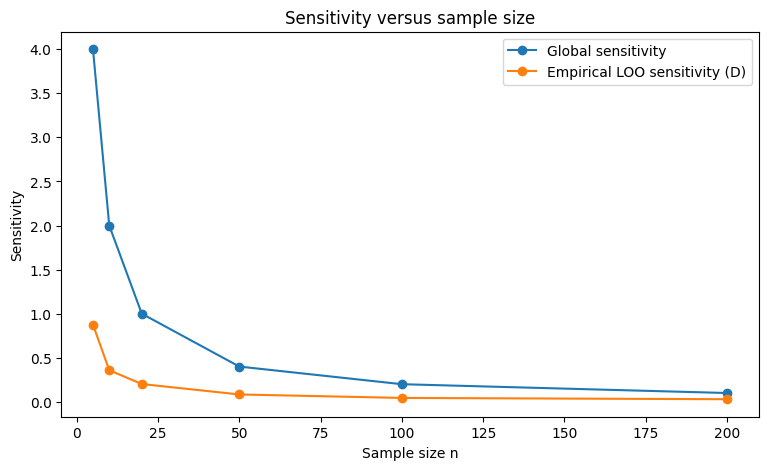

In [15]:
plt.figure(figsize=(9, 5))

plt.plot(
    sweep_df["n"],
    sweep_df["global_sensitivity"],
    marker="o",
    label="Global sensitivity",
)

plt.plot(
    sweep_df["n"],
    sweep_df["loo_sensitivity_D"],
    marker="o",
    label="Empirical LOO sensitivity (D)",
)

plt.xlabel("Sample size n")
plt.ylabel("Sensitivity")
plt.title("Sensitivity versus sample size")
plt.legend()
plt.show()

### Reading the sample-size sweep

For a bounded mean, global sensitivity decreases exactly as

$$
\frac{1}{n}.
$$

The empirical LOO sensitivity will also usually decrease with sample size, but it is determined by the particular generated dataset and can fluctuate.

This type of sweep is the bridge from a conceptual toy example to systematic simulation.

Other useful one-factor-at-a-time sweeps are:

- $\epsilon$;
- $\delta$;
- clipping width $U-L$;
- population variance;
- size of the one-subject replacement;
- location of the changed subject.

The next conceptual addition should be **privacy loss**, so that the distinguishability of neighboring output distributions is measured directly rather than inferred only from histograms and support gaps.

## 11. Privacy loss: quantify neighboring-dataset distinguishability

The previous sections compared output distributions visually and measured whether the rejection mechanism creates outputs that are impossible under a neighboring dataset.

We can now quantify the same idea more directly.

For a possible released value $y$, define the **privacy loss**

$$
L(y)
=
\log
\left(
\frac{p(y\mid D)}
     {p(y\mid D')}
\right).
$$

Here:

- $p(y\mid D)$ is the probability density of releasing $y$ when the private dataset is $D$;
- $p(y\mid D')$ is the corresponding density under the neighboring dataset.

Interpretation:

- $L(y)=0$: the release is equally plausible under both datasets;
- $L(y)>0$: the release favors $D$;
- $L(y)<0$: the release favors $D'$;
- a large $|L(y)|$: the release is much more informative about which dataset was used;
- $L(y)=+\infty$: $y$ is possible under $D$ but impossible under $D'$;
- $L(y)=-\infty$: the reverse is true.

Because

$$
\exp(L(y))
=
\frac{p(y\mid D)}
     {p(y\mid D')},
$$

a privacy loss of

$$
L(y)=\log(2)
$$

means that the output is twice as likely under $D$ as under $D'$.

This makes the neighboring-dataset idea concrete: privacy loss measures how much a particular released value helps distinguish the two possible private worlds.

In [16]:
def normal_logpdf(y, mean, sd):
    """Log-density of a Gaussian release distribution."""
    if sd <= 0:
        raise ValueError(
            "Noise SD must be positive for a continuous Gaussian density."
        )

    return norm.logpdf(
        y,
        loc=mean,
        scale=sd,
    )


def rejection_logpdf(
    y,
    mean,
    sd,
    sensitivity,
):
    """
    Log-density after Gaussian noise is repeatedly sampled until

        |noise| >= sensitivity.

    The accepted noise distribution is a Gaussian conditioned on lying
    outside the interval (-sensitivity, +sensitivity).
    """
    if sd <= 0:
        raise ValueError(
            "Noise SD must be positive for rejection-density analysis."
        )

    y = np.asarray(y, dtype=float)

    noise = y - mean

    # Probability that an ordinary Gaussian draw survives the rejection rule.
    acceptance_probability = (
        2 * norm.sf(sensitivity / sd)
    )

    log_density = np.full_like(
        y,
        -np.inf,
        dtype=float,
    )

    accepted = np.abs(noise) >= sensitivity

    # Conditional density:
    #
    # p(z | accepted)
    # =
    # p(z) / P(accepted)
    log_density[accepted] = (
        norm.logpdf(
            noise[accepted],
            loc=0.0,
            scale=sd,
        )
        - np.log(acceptance_probability)
    )

    return log_density

### 11.1 Dataset-dependent Gaussian width

For the first diagnostic mechanism,

$$
M(D)
\sim
\mathcal{N}
\left(
\bar{x}_D,
\sigma_D^2
\right)
$$

and

$$
M(D')
\sim
\mathcal{N}
\left(
\bar{x}_{D'},
\sigma_{D'}^2
\right).
$$

Both distributions have non-zero density everywhere, so there are no hard support gaps.

However, both the center and the width can differ between neighboring datasets because $\sigma_D$ is calculated from the private LOO scale.

The privacy-loss curve below shows which released values favor which neighboring dataset.

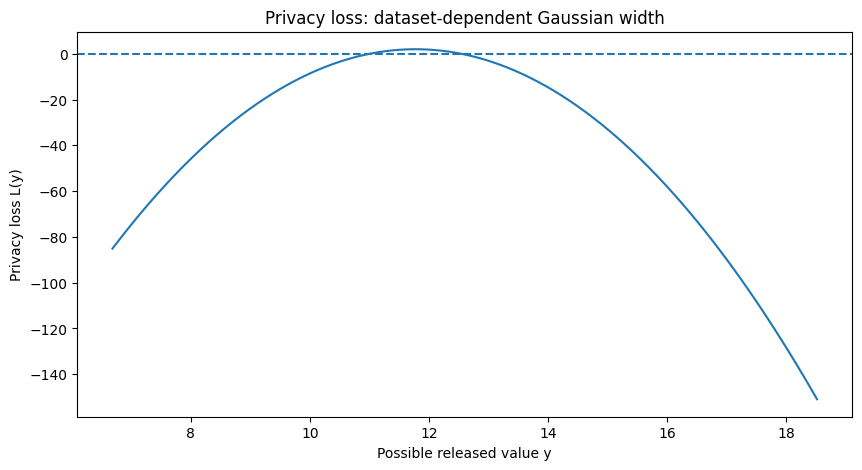

In [17]:
# Build a plotting range that focuses on the dataset-dependent mechanism.
prototype_plot_sd = max(
    prototype_sd_D,
    prototype_sd_N,
)

prototype_y = np.linspace(
    min(mean_D, mean_N) - 6 * prototype_plot_sd,
    max(mean_D, mean_N) + 6 * prototype_plot_sd,
    5000,
)

prototype_log_p_D = normal_logpdf(
    prototype_y,
    mean_D,
    prototype_sd_D,
)

prototype_log_p_N = normal_logpdf(
    prototype_y,
    mean_N,
    prototype_sd_N,
)

prototype_privacy_loss = (
    prototype_log_p_D
    - prototype_log_p_N
)

plt.figure(figsize=(10, 5))

plt.plot(
    prototype_y,
    prototype_privacy_loss,
)

plt.axhline(
    0,
    linestyle="--",
)

plt.xlabel("Possible released value y")
plt.ylabel("Privacy loss L(y)")
plt.title(
    "Privacy loss: dataset-dependent Gaussian width"
)

plt.show()

#### What this plot means

The curve is not expected to stay near zero.

A positive region means those releases are more characteristic of $D$; a negative region means they are more characteristic of $D'$.

Because the two Gaussian widths can differ, the privacy loss can become very large in the tails. Therefore this diagnostic mechanism is not a pure $\epsilon$-DP mechanism for any finite $\epsilon$.

That does **not** by itself tell us whether some approximate $(\epsilon,\delta)$ guarantee could be derived. It tells us that the current dataset-dependent calibration has not supplied such a guarantee automatically.

### Why the unequal-variance privacy-loss curve bends

For equal-variance Gaussians, the log density ratio is linear in the released value $y$.

For the dataset-dependent Gaussian diagnostic, the neighboring datasets can have different noise variances. The log density ratio then contains a quadratic term in $y$.

In the scalar LOO experiments, neighboring differences in the estimated LOO scale often become small as $n$ increases, so the curve can look nearly linear over the high-probability region.

However, the variance difference still matters theoretically: unequal Gaussian variances make the privacy loss unbounded in at least one tail. Therefore the apparently mild central part of the curve should not be mistaken for a global DP guarantee.

### 11.2 Prototype sensitivity-rejection mechanism

The rejection mechanism only allows outputs satisfying

$$
|y-\bar{x}|
\geq
\Delta_{\mathrm{LOO}}.
$$

Therefore the output distribution has a gap around the unperturbed statistic.

For $D$, the forbidden interval is

$$
\left(
\bar{x}_D-\Delta_D,
\;
\bar{x}_D+\Delta_D
\right).
$$

For $D'$, it is

$$
\left(
\bar{x}_{D'}-\Delta_{D'},
\;
\bar{x}_{D'}+\Delta_{D'}
\right).
$$

Because the mean and empirical sensitivity are dataset-specific, these two forbidden regions generally differ.

This can create outputs that have positive probability under one neighboring dataset and exactly zero probability under the other.

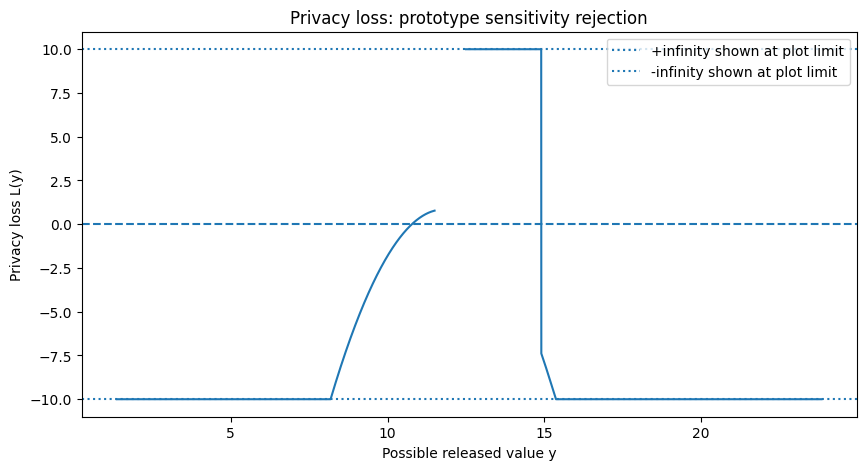

Grid points possible only under D: 641
Grid points possible only under D_neighbor: 0


In [18]:
rejection_sd_D = (
    CONFIG["rejection_noise_multiplier"]
    * scale_D
)

rejection_sd_N = (
    CONFIG["rejection_noise_multiplier"]
    * scale_N
)

rejection_plot_sd = max(
    rejection_sd_D,
    rejection_sd_N,
)

rejection_y = np.linspace(
    min(mean_D, mean_N) - 6 * rejection_plot_sd,
    max(mean_D, mean_N) + 6 * rejection_plot_sd,
    6000,
)

reject_log_p_D = rejection_logpdf(
    rejection_y,
    mean_D,
    rejection_sd_D,
    sens_D,
)

reject_log_p_N = rejection_logpdf(
    rejection_y,
    mean_N,
    rejection_sd_N,
    sens_N,
)

both_possible = (
    np.isfinite(reject_log_p_D)
    & np.isfinite(reject_log_p_N)
)

only_D = (
    np.isfinite(reject_log_p_D)
    & ~np.isfinite(reject_log_p_N)
)

only_neighbor = (
    ~np.isfinite(reject_log_p_D)
    & np.isfinite(reject_log_p_N)
)

neither_possible = (
    ~np.isfinite(reject_log_p_D)
    & ~np.isfinite(reject_log_p_N)
)

reject_privacy_loss = np.full_like(
    rejection_y,
    np.nan,
    dtype=float,
)

reject_privacy_loss[both_possible] = (
    reject_log_p_D[both_possible]
    - reject_log_p_N[both_possible]
)

reject_privacy_loss[only_D] = np.inf
reject_privacy_loss[only_neighbor] = -np.inf

# Infinity cannot be displayed directly on a useful plot.
# Clip only for visualization; the underlying values remain infinite.
display_limit = 10.0

reject_privacy_loss_display = np.clip(
    reject_privacy_loss,
    -display_limit,
    display_limit,
)

plt.figure(figsize=(10, 5))

plt.plot(
    rejection_y,
    reject_privacy_loss_display,
)

plt.axhline(
    0,
    linestyle="--",
)

plt.axhline(
    display_limit,
    linestyle=":",
    label="+infinity shown at plot limit",
)

plt.axhline(
    -display_limit,
    linestyle=":",
    label="-infinity shown at plot limit",
)

plt.xlabel("Possible released value y")
plt.ylabel("Privacy loss L(y)")
plt.title(
    "Privacy loss: prototype sensitivity rejection"
)

plt.legend()
plt.show()

print(
    "Grid points possible only under D:",
    np.sum(only_D),
)

print(
    "Grid points possible only under D_neighbor:",
    np.sum(only_neighbor),
)

### A concrete lower bound on $\delta$

The support mismatch gives an especially simple approximate-DP diagnostic.

Suppose there is an event $S$ such that

$$
P(M(D)\in S) > 0
$$

but

$$
P(M(D')\in S)=0.
$$

The $(\epsilon,\delta)$-DP inequality requires

$$
P(M(D)\in S)
\leq
e^\epsilon P(M(D')\in S)+\delta.
$$

Since the second probability is zero,

$$
P(M(D)\in S)
\leq
\delta.
$$

Therefore,

$$
\delta
\geq
P(M(D)\in S).
$$

So if, for example, 40% of the releases from $D$ fall in a region that is impossible under $D'$, **no claimed $(\epsilon,\delta)$ guarantee can have $\delta<0.4$ for this neighboring pair**, regardless of the value of $\epsilon$.

This turns the support-gap problem into a directly interpretable quantity.

In [19]:
# We already estimated both exclusive-output probabilities using Monte Carlo:
#
# exclusive_prob_D
# =
# P(output generated under D is impossible under D_neighbor)
#
# exclusive_prob_N
# =
# P(output generated under D_neighbor is impossible under D)

delta_support_lower_bound = max(
    exclusive_prob_D,
    exclusive_prob_N,
)

print(
    "Exclusive-output probability, D -> impossible under neighbor:",
    exclusive_prob_D,
)

print(
    "Exclusive-output probability, neighbor -> impossible under D:",
    exclusive_prob_N,
)

print(
    "\nLower bound on delta implied by support mismatch:",
    delta_support_lower_bound,
)

Exclusive-output probability, D -> impossible under neighbor: 0.49944
Exclusive-output probability, neighbor -> impossible under D: 0.0

Lower bound on delta implied by support mismatch: 0.49944


### 11.3 Formally calibrated Gaussian comparison

For the formal Gaussian comparison, both neighboring datasets use the same noise standard deviation:

$$
M(D)
\sim
\mathcal{N}
\left(
\bar{x}_D,
\sigma^2
\right),
$$

$$
M(D')
\sim
\mathcal{N}
\left(
\bar{x}_{D'},
\sigma^2
\right).
$$

Gaussian noise has non-zero density everywhere, so every finite output is possible under both neighboring datasets.

However, the Gaussian mechanism is an **approximate** DP mechanism.

This means the privacy-loss curve does **not** have to remain between $-\epsilon$ and $+\epsilon$ for every possible output. Extreme-tail outputs can have privacy loss larger than $\epsilon$.

The role of $\delta$ is to allow a tightly controlled amount of probability mass where the pure $\epsilon$ bound would otherwise be violated. Importantly, $\delta$ is not simply equal to the probability that $|L(y)|>\epsilon$; the exact $(\epsilon,\delta)$ condition is a probability-distribution inequality.

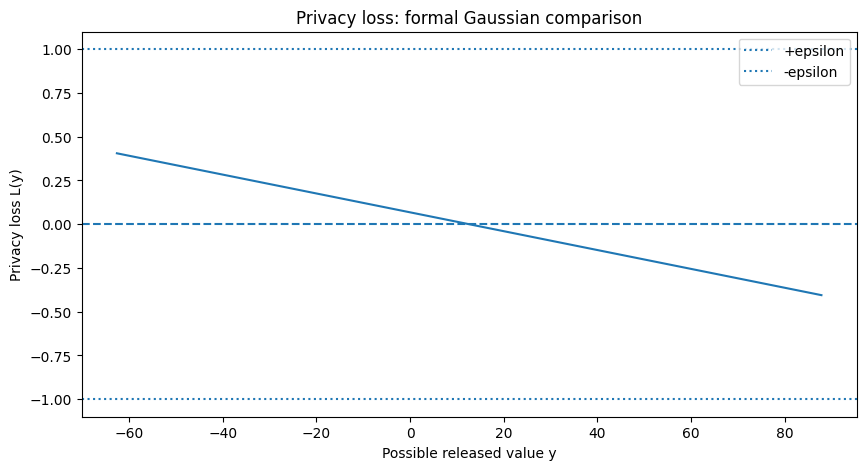

In [20]:
formal_y = np.linspace(
    min(mean_D, mean_N) - 5 * gaussian_sd,
    max(mean_D, mean_N) + 5 * gaussian_sd,
    6000,
)

formal_log_p_D = normal_logpdf(
    formal_y,
    mean_D,
    gaussian_sd,
)

formal_log_p_N = normal_logpdf(
    formal_y,
    mean_N,
    gaussian_sd,
)

formal_privacy_loss = (
    formal_log_p_D
    - formal_log_p_N
)

plt.figure(figsize=(10, 5))

plt.plot(
    formal_y,
    formal_privacy_loss,
)

plt.axhline(
    0,
    linestyle="--",
)

plt.axhline(
    epsilon,
    linestyle=":",
    label="+epsilon",
)

plt.axhline(
    -epsilon,
    linestyle=":",
    label="-epsilon",
)

plt.xlabel("Possible released value y")
plt.ylabel("Privacy loss L(y)")
plt.title(
    "Privacy loss: formal Gaussian comparison"
)

plt.legend()
plt.show()

### Comparing the three privacy-loss plots

The mechanisms now differ in a very concrete way:

**Dataset-dependent Gaussian**

- full support everywhere;
- neighboring datasets can have different centers and different widths;
- privacy loss can become large because the noise distribution itself changes with the data.

**Prototype rejection**

- dataset-dependent center, width, and forbidden region;
- some outputs can be possible under only one neighboring dataset;
- these regions produce infinite privacy loss;
- their probability mass gives a lower bound on any possible $\delta$.

**Formal Gaussian comparison**

- same noise width for both neighboring datasets;
- full support everywhere;
- privacy loss can exceed $\epsilon$ only in the approximate-DP sense controlled by the Gaussian calibration.

This is why a mechanism can look excellent against a reconstruction attack while still fail to provide a useful differential-privacy guarantee: the two criteria measure different things.

## 12. What do $\epsilon$ and $\delta$ mean here?

We can now connect the privacy-loss plots to the formal definition of approximate differential privacy.

A randomized mechanism $M$ is $(\epsilon,\delta)$-DP if, for every neighboring pair $D,D'$ and every possible set of outputs $S$,

$$
P(M(D)\in S)
\leq
e^\epsilon P(M(D')\in S)
+
\delta.
$$

Because neighboring adjacency is symmetric, the same requirement must also hold with $D$ and $D'$ exchanged.

### Meaning of $\epsilon$

Ignoring $\delta$ for a moment, $\epsilon$ limits how different the output probabilities may be between neighboring datasets.

If

$$
\epsilon = 1,
$$

then

$$
e^\epsilon \approx 2.72.
$$

So the DP inequality allows an event to be up to about $2.72$ times as likely under one neighboring dataset as under the other, before the additive $\delta$ allowance is used.

Smaller $\epsilon$ means the two output distributions must be more similar.

### Meaning of $\delta$

$\delta$ is an additive allowance for a small amount of probability mass where the pure $\epsilon$ bound is exceeded.

It is important **not** to interpret $\delta$ simply as

> "the probability that privacy fails."

The exact definition is the probability-distribution inequality above.

For a fixed neighboring pair, $\delta$ is the amount of excess probability needed to make that inequality hold.

### 12.1 Privacy loss under equal-variance Gaussian releases

For the formal Gaussian comparison,

$$
M(D)
\sim
\mathcal{N}(\mu_D,\sigma^2)
$$

and

$$
M(D')
\sim
\mathcal{N}(\mu_{D'},\sigma^2).
$$

Let

$$
d = |\mu_D-\mu_{D'}|
$$

and define the standardized separation

$$
\alpha = \frac{d}{\sigma}.
$$

The privacy-loss random variable under $D$ has a Gaussian distribution:

$$
L
\sim
\mathcal{N}
\left(
\frac{\alpha^2}{2},
\alpha^2
\right).
$$

Under the neighboring dataset, the privacy-loss distribution is mirrored:

$$
L
\sim
\mathcal{N}
\left(
-\frac{\alpha^2}{2},
\alpha^2
\right).
$$

This is useful because it shows that privacy depends on the **distance between neighboring statistics relative to the noise scale**.

If $d$ is tiny compared with $\sigma$, then $\alpha$ is small and the two output distributions are difficult to distinguish.

In [21]:
mean_difference = abs(mean_D - mean_N)
alpha_actual = mean_difference / gaussian_sd

print("Actual neighboring mean difference:", mean_difference)
print("Formal Gaussian noise SD:", gaussian_sd)
print("Standardized separation alpha:", alpha_actual)

privacy_loss_mean_D = alpha_actual**2 / 2
privacy_loss_sd = alpha_actual

print("\nPrivacy-loss distribution under D:")
print("  mean:", privacy_loss_mean_D)
print("  SD:  ", privacy_loss_sd)

print("\nPrivacy-loss distribution under D_neighbor:")
print("  mean:", -privacy_loss_mean_D)
print("  SD:  ", privacy_loss_sd)

Actual neighboring mean difference: 1.1999999999999993
Formal Gaussian noise SD: 14.922526539274259
Standardized separation alpha: 0.08041533696333168

Privacy-loss distribution under D:
  mean: 0.0032333132094630895
  SD:   0.08041533696333168

Privacy-loss distribution under D_neighbor:
  mean: -0.0032333132094630895
  SD:   0.08041533696333168


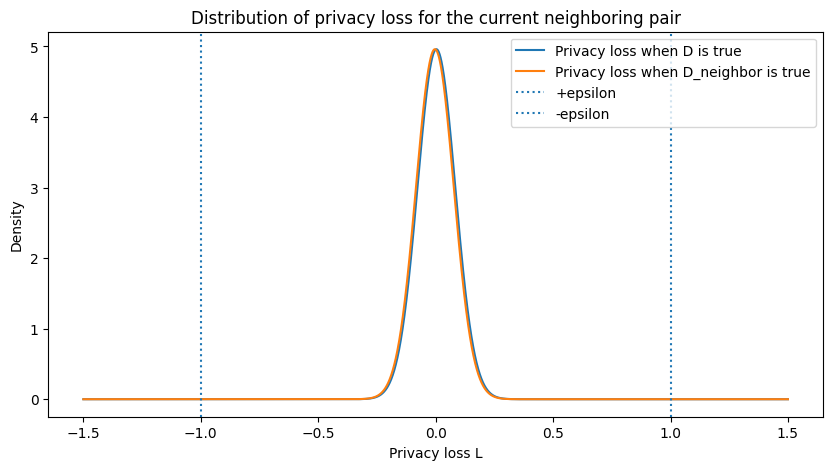

In [22]:
# Plot the privacy-loss random-variable distributions analytically.

if privacy_loss_sd > 0:
    L_min = min(
        -epsilon * 1.5,
        -privacy_loss_mean_D - 5 * privacy_loss_sd,
    )
    L_max = max(
        epsilon * 1.5,
        privacy_loss_mean_D + 5 * privacy_loss_sd,
    )

    L_grid = np.linspace(
        L_min,
        L_max,
        5000,
    )

    density_L_under_D = norm.pdf(
        L_grid,
        loc=privacy_loss_mean_D,
        scale=privacy_loss_sd,
    )

    density_L_under_N = norm.pdf(
        L_grid,
        loc=-privacy_loss_mean_D,
        scale=privacy_loss_sd,
    )

    plt.figure(figsize=(10, 5))

    plt.plot(
        L_grid,
        density_L_under_D,
        label="Privacy loss when D is true",
    )

    plt.plot(
        L_grid,
        density_L_under_N,
        label="Privacy loss when D_neighbor is true",
    )

    plt.axvline(
        epsilon,
        linestyle=":",
        label="+epsilon",
    )

    plt.axvline(
        -epsilon,
        linestyle=":",
        label="-epsilon",
    )

    plt.xlabel("Privacy loss L")
    plt.ylabel("Density")
    plt.title(
        "Distribution of privacy loss for the current neighboring pair"
    )

    plt.legend()
    plt.show()
else:
    print(
        "The neighboring means are identical, so the privacy loss is zero."
    )

### 12.2 Why $\delta$ is not just $P(|L|>\epsilon)$

For the ordered comparison $D$ versus $D'$, the worst event is the region where the privacy loss exceeds $\epsilon$:

$$
S_\epsilon
=
\{y:L(y)>\epsilon\}.
$$

For this event, the required additive slack is

$$
\delta_{D\rightarrow D'}
=
P_D(S_\epsilon)
-
e^\epsilon P_{D'}(S_\epsilon).
$$

If this expression is negative, no positive slack is needed for that direction, so it is clipped at zero.

The reverse comparison uses the corresponding region where

$$
L(y)<-\epsilon.
$$

This explains why simply counting the probability that $|L|>\epsilon$ is not the formal definition of $\delta$.

The neighboring distribution's probability is subtracted after being multiplied by $e^\epsilon$.

In [23]:
actual_pair_delta = gaussian_pair_delta(
    mean_difference,
    gaussian_sd,
    epsilon,
)

worst_case_delta_at_global_sensitivity = gaussian_pair_delta(
    global_sensitivity,
    gaussian_sd,
    epsilon,
)

print("Configured delta:", delta)

print(
    "\nExact delta required for the actual D vs D_neighbor pair:",
    actual_pair_delta,
)

print(
    "Exact delta required for a worst-case mean shift "
    "equal to global sensitivity:",
    worst_case_delta_at_global_sensitivity,
)

Configured delta: 1e-05

Exact delta required for the actual D vs D_neighbor pair: 8.826850833960546e-38
Exact delta required for a worst-case mean shift equal to global sensitivity: 9.999999999883529e-06


### Interpreting these three $\delta$ values

There are now three different quantities:

1. **Configured $\delta$**

   This is the privacy parameter supplied to the Gaussian calibration.

2. **Exact $\delta$ for the current $D,D'$ pair**

   This asks how much additive slack is actually needed for this particular neighboring pair.

3. **Exact $\delta$ for a worst-case shift of $\Delta_{\mathrm{global}}$**

   This evaluates a pair whose released means differ by the largest amount allowed by the sensitivity bound.

The current neighboring pair often requires a much smaller $\delta$ than the configured value because

$$
|\mu_D-\mu_{D'}|
<
\Delta_{\mathrm{global}}.
$$

That is expected.

Formal DP calibrates the mechanism for the **worst valid neighboring pair**, not only for the particular pair we happened to simulate.

The formal mechanisms in this notebook now use analytic Gaussian calibration. For a worst-case shift equal to the sensitivity bound, the exact Gaussian $\delta$ should therefore be approximately the configured target, up to numerical tolerance.

### 12.3 Compare the prototype rejection mechanism with the requested $\delta$

Earlier we obtained a lower bound on $\delta$ from the rejection mechanism's support mismatch:

$$
\delta
\geq
P(\text{output possible under one neighbor but impossible under the other}).
$$

We can now compare that lower bound with the formal target `CONFIG["delta"]`.

If the support-induced lower bound is much larger than the requested $\delta$, then the rejection mechanism cannot satisfy that requested $(\epsilon,\delta)$ guarantee for the tested neighboring pair, regardless of how favorable the finite privacy-loss values are elsewhere.

In [24]:
comparison = pd.DataFrame([
    {
        "quantity": "Requested delta",
        "value": delta,
    },
    {
        "quantity": "Exact delta: actual Gaussian pair",
        "value": actual_pair_delta,
    },
    {
        "quantity": "Exact delta: Gaussian worst-case sensitivity shift",
        "value": worst_case_delta_at_global_sensitivity,
    },
    {
        "quantity": "Rejection support lower bound on delta",
        "value": delta_support_lower_bound,
    },
])

comparison

,quantity,value
0,Requested delta,1.000000e-05
1,Exact delta: actual Gaussian pair,8.826851e-38
2,Exact delta: Gaussian worst-case sensitivity s...,1.000000e-05
3,Rejection support lower bound on delta,4.994400e-01


### Main interpretation of $\epsilon$ and $\delta$

The formal Gaussian mechanism and the prototype rejection mechanism can now be compared in the same language.

For the formal Gaussian mechanism:

- every finite output is possible under both neighboring datasets;
- privacy loss varies continuously;
- the noise scale is calibrated so that the full $(\epsilon,\delta)$ inequality holds for all neighboring datasets permitted by the sensitivity bound.

For the rejection prototype:

- the dataset-specific rejection threshold creates different forbidden regions;
- some outputs may be impossible under one neighbor;
- the probability mass of those exclusive regions alone can already force $\delta$ to be large.

This is the practical reason that "adding enough noise to defeat reconstruction" and "satisfying differential privacy" are separate claims.

## 13. Reconstruction attack

We now return to the attack that motivated the original prototype.

For a dataset with $n$ subjects,

$$
D = \{x_1,\ldots,x_n\},
$$

define the leave-one-out mean for subject $i$ as

$$
\bar{x}_{-i}
=
\frac{1}{n-1}
\sum_{j\neq i} x_j.
$$

If all exact LOO means are available, their average equals the full-data mean:

$$
\frac{1}{n}
\sum_{i=1}^{n}
\bar{x}_{-i}
=
\bar{x}.
$$

Therefore an attacker can reconstruct subject $i$ exactly using

$$
x_i
=
n\bar{x}
-
(n-1)\bar{x}_{-i}.
$$

This is the key reconstruction identity.

The experiment below asks what happens when the attacker receives **noisy LOO means** instead of exact ones.

This is a different question from formal DP:

- reconstruction error measures how well this particular algebraic attack works;
- differential privacy measures how distinguishable neighboring datasets are under the randomized mechanism.

In [25]:
def exact_loo_means(data):
    data = np.asarray(data, dtype=float)

    return np.array([
        np.mean(np.delete(data, i))
        for i in range(len(data))
    ])


def reconstruct_from_loo_means(noisy_loo_means):
    """
    Reconstruct all subject values from a vector of LOO means.

    The attacker estimates the full mean as the average of the released
    LOO means, then applies:

        x_i = n * mean - (n - 1) * loo_mean_i
    """
    noisy_loo_means = np.asarray(
        noisy_loo_means,
        dtype=float,
    )

    n = len(noisy_loo_means)

    estimated_full_mean = np.mean(
        noisy_loo_means
    )

    reconstructed = (
        n * estimated_full_mean
        - (n - 1) * noisy_loo_means
    )

    return reconstructed, estimated_full_mean

### 13.1 Exact reconstruction baseline

Before adding privacy noise, verify that the reconstruction identity works.

If the exact LOO means are released, the reconstruction error should be numerical zero.

This is why repeated aggregate releases can reveal much more than any single mean appears to reveal on its own.

### All LOO means together are an invertible encoding of the raw data

The reconstruction identity is not an accident.

Let

$$
x =
\begin{bmatrix}
x_1\\
\vdots\\
x_n
\end{bmatrix}
$$

contain the raw subject values and let

$$
v =
\begin{bmatrix}
\bar{x}_{-1}\\
\vdots\\
\bar{x}_{-n}
\end{bmatrix}
$$

contain all LOO means.

Then

$$
v = Ax
$$

for a fixed linear transformation $A$.

For $n>1$, this transformation is invertible. Equivalently, the reconstruction formula

$$
x_i
=
n\bar{x}
-
(n-1)\bar{x}_{-i}
$$

recovers every original coordinate, and the full mean itself is recoverable as the average of the LOO means.

Therefore:

> Releasing all exact LOO means is not merely "somewhat revealing"; it is a one-to-one linear encoding of the original scalar microdata.

This is the sharpest reason the exact reconstruction attack succeeds, and it also explains why one final aggregate release is fundamentally different from releasing all LOO statistics.

In [26]:
loo_exact_D = exact_loo_means(D)

reconstructed_exact_D, estimated_mean_exact_D = (
    reconstruct_from_loo_means(
        loo_exact_D
    )
)

exact_reconstruction_table = pd.DataFrame({
    "true_value": D,
    "exact_loo_mean": loo_exact_D,
    "reconstructed_value": reconstructed_exact_D,
    "error": reconstructed_exact_D - D,
})

print(
    "True full mean:",
    np.mean(D),
)

print(
    "Full mean recovered from exact LOO means:",
    estimated_mean_exact_D,
)

print(
    "Maximum absolute reconstruction error:",
    np.max(np.abs(
        reconstructed_exact_D - D
    )),
)

exact_reconstruction_table

True full mean: 12.0
Full mean recovered from exact LOO means: 12.0
Maximum absolute reconstruction error: 0.0


,true_value,exact_loo_mean,reconstructed_value,error
0,10.0,12.50,10.0,0.0
1,11.0,12.25,11.0,0.0
2,12.0,12.00,12.0,0.0
3,13.0,11.75,13.0,0.0
4,14.0,11.50,14.0,0.0


### Treat all LOO means as one vector-valued query

The earlier composition-aware mechanism treated the $n$ LOO releases as $n$ separate DP mechanisms and divided the total privacy budget across them.

That is valid but unnecessarily pessimistic because the LOO means are highly redundant.

Instead define one vector-valued query

$$
v(D)
=
\begin{bmatrix}
\bar{x}_{-1}\\
\vdots\\
\bar{x}_{-n}
\end{bmatrix}.
$$

Suppose neighboring datasets differ by replacing subject $k$, changing its value by

$$
\Delta x.
$$

Then:

- the $k$-th LOO mean is unchanged, because it excludes subject $k$;
- every other LOO mean changes by exactly
  $$
  \frac{\Delta x}{n-1}.
  $$

Therefore the joint $L_2$ change is

$$
\|\Delta v\|_2
=
\sqrt{n-1}
\frac{|\Delta x|}{n-1}
=
\frac{|\Delta x|}{\sqrt{n-1}}.
$$

With public bounds $x\in[L,U]$,

$$
\boxed{
\Delta_2(v)
\leq
\frac{U-L}{\sqrt{n-1}}
}.
$$

We can therefore privatize **the entire LOO vector with one Gaussian mechanism** calibrated to this joint sensitivity.

This is a much fairer formal baseline than splitting $\epsilon/n$ and $\delta/n$ across all LOO coordinates.

### Adjacency caveat

The joint sensitivity result

$$
\Delta_2(v)
\leq
\frac{U-L}{\sqrt{n-1}}
$$

assumes **fixed-size replacement adjacency**:

- both neighboring datasets contain the same number $n$ of subjects;
- one subject value is replaced by another valid value in $[L,U]$.

If we switch to add/remove adjacency, the neighboring datasets have different cardinalities and the LOO vector itself changes dimension. The sensitivity derivation must then be reformulated.

The same warning will matter later for covariance: sensitivity formulas are only meaningful together with a clearly stated neighboring-dataset definition.

### 13.2 Noise parameters for every LOO release

To attack all $n$ subjects, the attacker receives $n$ different LOO means.

For the prototype mechanisms, each LOO dataset has its own:

- LOO scale;
- empirical sensitivity;
- noise width.

For the Gaussian DP comparison, every LOO query has the same public sensitivity bound because every LOO dataset contains $n-1$ records:

$$
\Delta_{\mathrm{LOO\ query}}
=
\frac{U-L}{n-1}.
$$

There is an important privacy-accounting issue here.

If each of the $n$ LOO means is released with privacy budget $(\epsilon,\delta)$, the collection of all releases is **not** automatically $(\epsilon,\delta)$-DP.

Under basic sequential composition, a conservative bound is

$$
\epsilon_{\mathrm{total}}
\leq
\sum_i \epsilon_i
$$

and

$$
\delta_{\mathrm{total}}
\leq
\sum_i \delta_i.
$$

Therefore we compare two Gaussian versions:

1. **Per-query Gaussian**: each LOO mean uses the full configured $\epsilon,\delta$. This is useful as an attack diagnostic but does not preserve the same total privacy budget across all releases.
2. **Composition-aware Gaussian**: split the configured total budget equally across the $n$ LOO releases using basic composition.

In [27]:
def loo_release_parameters(
    data,
    config,
):
    """
    Precompute prototype noise parameters for each LOO dataset.

    For subject i, the released statistic is the mean of D without i.
    The prototype parameters are then estimated from that LOO dataset.
    """
    data = np.asarray(data, dtype=float)

    if len(data) < 3:
        raise ValueError(
            "Reconstruction experiment requires at least 3 subjects."
        )

    n = len(data)

    loo_means = exact_loo_means(data)

    prototype_sds = np.empty(n)
    rejection_sds = np.empty(n)
    rejection_sensitivities = np.empty(n)

    for i in range(n):
        loo_dataset = np.delete(data, i)

        (
            _,
            _,
            loo_sensitivity,
            loo_scale,
        ) = empirical_loo_sensitivity(
            loo_dataset
        )

        prototype_sds[i] = (
            config["prototype_noise_multiplier"]
            * loo_scale
            / config["epsilon"]
        )

        rejection_sds[i] = (
            config["rejection_noise_multiplier"]
            * loo_scale
        )

        rejection_sensitivities[i] = (
            loo_sensitivity
        )

    loo_query_global_sensitivity = (
        config["upper_bound"]
        - config["lower_bound"]
    ) / (n - 1)

    # Joint L2 sensitivity of the entire vector of n LOO means.
    loo_vector_l2_sensitivity = (
        config["upper_bound"]
        - config["lower_bound"]
    ) / np.sqrt(n - 1)

    loo_vector_gaussian_sd = (
        analytic_gaussian_dp_sd(
            loo_vector_l2_sensitivity,
            config["epsilon"],
            config["delta"],
        )
    )

    per_query_gaussian_sd = (
        analytic_gaussian_dp_sd(
            loo_query_global_sensitivity,
            config["epsilon"],
            config["delta"],
        )
    )

    # Conservative equal split under basic composition.
    epsilon_per_query = (
        config["epsilon"] / n
    )

    delta_per_query = (
        config["delta"] / n
    )

    composition_gaussian_sd = (
        analytic_gaussian_dp_sd(
            loo_query_global_sensitivity,
            epsilon_per_query,
            delta_per_query,
        )
    )

    return {
        "loo_means": loo_means,
        "prototype_sds": prototype_sds,
        "rejection_sds": rejection_sds,
        "rejection_sensitivities": rejection_sensitivities,
        "loo_query_global_sensitivity": (
            loo_query_global_sensitivity
        ),
        "loo_vector_l2_sensitivity": (
            loo_vector_l2_sensitivity
        ),
        "loo_vector_gaussian_sd": (
            loo_vector_gaussian_sd
        ),
        "per_query_gaussian_sd": (
            per_query_gaussian_sd
        ),
        "composition_gaussian_sd": (
            composition_gaussian_sd
        ),
        "epsilon_per_query": epsilon_per_query,
        "delta_per_query": delta_per_query,
    }


reconstruction_params_D = loo_release_parameters(
    D,
    CONFIG,
)

print(
    "Global sensitivity of each LOO-mean query:",
    reconstruction_params_D[
        "loo_query_global_sensitivity"
    ],
)

print(
    "Gaussian SD if every query uses the full epsilon/delta:",
    reconstruction_params_D[
        "per_query_gaussian_sd"
    ],
)

print(
    "Per-query epsilon after equal budget split:",
    reconstruction_params_D[
        "epsilon_per_query"
    ],
)

print(
    "Per-query delta after equal budget split:",
    reconstruction_params_D[
        "delta_per_query"
    ],
)

print(
    "Gaussian SD after composition-aware budget split:",
    reconstruction_params_D[
        "composition_gaussian_sd"
    ],
)

print(
    "\nJoint L2 sensitivity of the full LOO vector:",
    reconstruction_params_D[
        "loo_vector_l2_sensitivity"
    ],
)

print(
    "Analytic Gaussian SD for the full LOO vector:",
    reconstruction_params_D[
        "loo_vector_gaussian_sd"
    ],
)


Global sensitivity of each LOO-mean query: 5.0
Gaussian SD if every query uses the full epsilon/delta: 18.653158174092823
Per-query epsilon after equal budget split: 0.2
Per-query delta after equal budget split: 2.0000000000000003e-06
Gaussian SD after composition-aware budget split: 91.04593805896002

Joint L2 sensitivity of the full LOO vector: 10.0
Analytic Gaussian SD for the full LOO vector: 37.306316348185646


### 13.3 Simulate noisy LOO release sets

One Monte Carlo trial now consists of:

1. generate one noisy release of every LOO mean;
2. give the full vector of noisy LOO means to the attacker;
3. estimate the full mean from their average;
4. reconstruct every subject;
5. compare reconstructed values with the true data.

We repeat this many times and summarize the reconstruction error.

The same reconstruction algorithm is used for every mechanism. Only the way the LOO means are randomized changes.

### Rejection-sampling validity and trial dropping

The rejection prototype can fail to find an accepted draw within `max_attempts`.

If even one coordinate in a release set remains missing, the current reconstruction code excludes that whole trial from the attack summary.

When

```text
valid_fraction = 1.0
```

this has no practical effect.

If `valid_fraction` falls below 1, however, the retained trials are conditioned on successful rejection sampling and can become a biased subset of all attempted releases.

Therefore the notebook reports `valid_fraction` explicitly. Any scenario with substantial rejection failures should be treated cautiously rather than interpreted only from the retained reconstruction RMSE.

In [28]:
def sample_rejection_noise_matrix(
    sds,
    sensitivities,
    n_draws,
    rng,
    max_attempts=10_000,
):
    """
    Draw a matrix of independently rejected Gaussian noise values.

    Shape:
        (n_draws, n_queries)

    Each query/column can have its own SD and rejection threshold.
    """
    sds = np.asarray(sds, dtype=float)
    sensitivities = np.asarray(
        sensitivities,
        dtype=float,
    )

    if np.any(sds <= 0):
        raise ValueError(
            "All rejection noise SDs must be positive."
        )

    n_queries = len(sds)

    noise = np.full(
        (n_draws, n_queries),
        np.nan,
        dtype=float,
    )

    unresolved = np.ones(
        (n_draws, n_queries),
        dtype=bool,
    )

    for _ in range(max_attempts):
        if not np.any(unresolved):
            break

        rows, cols = np.where(unresolved)

        candidates = rng.normal(
            loc=0.0,
            scale=sds[cols],
        )

        accepted = (
            np.abs(candidates)
            >= sensitivities[cols]
        )

        accepted_rows = rows[accepted]
        accepted_cols = cols[accepted]

        noise[
            accepted_rows,
            accepted_cols,
        ] = candidates[accepted]

        unresolved[
            accepted_rows,
            accepted_cols,
        ] = False

    return noise


def reconstruct_many_release_sets(
    noisy_loo_release_matrix,
):
    """
    Vectorized reconstruction.

    Input shape:
        (n_trials, n_subjects)

    Output shape:
        (n_trials, n_subjects)
    """
    releases = np.asarray(
        noisy_loo_release_matrix,
        dtype=float,
    )

    n = releases.shape[1]

    estimated_means = np.mean(
        releases,
        axis=1,
        keepdims=True,
    )

    reconstructed = (
        n * estimated_means
        - (n - 1) * releases
    )

    return reconstructed


def reconstruction_metrics(
    reconstructed,
    true_data,
):
    true_data = np.asarray(
        true_data,
        dtype=float,
    )

    errors = (
        reconstructed
        - true_data[None, :]
    )

    rmse_per_trial = np.sqrt(
        np.mean(
            errors**2,
            axis=1,
        )
    )

    mae_per_trial = np.mean(
        np.abs(errors),
        axis=1,
    )

    max_abs_error_per_trial = np.max(
        np.abs(errors),
        axis=1,
    )

    return {
        "errors": errors,
        "rmse_per_trial": rmse_per_trial,
        "mae_per_trial": mae_per_trial,
        "max_abs_error_per_trial": (
            max_abs_error_per_trial
        ),
    }

In [29]:
def run_reconstruction_experiment(
    data,
    config,
):
    data = np.asarray(data, dtype=float)
    n = len(data)

    params = loo_release_parameters(
        data,
        config,
    )

    loo_means = params["loo_means"]

    n_draws = int(
        config["reconstruction_draws"]
    )

    ss = np.random.SeedSequence(
        int(config["seed"]) + 10_000
    )

    streams = [
        np.random.default_rng(s)
        for s in ss.spawn(5)
    ]

    # A. Dataset-dependent Gaussian prototype
    prototype_noise = streams[0].normal(
        loc=0.0,
        scale=params["prototype_sds"][None, :],
        size=(n_draws, n),
    )

    prototype_releases = (
        loo_means[None, :]
        + prototype_noise
    )

    # B. Prototype with sensitivity rejection
    rejection_noise = (
        sample_rejection_noise_matrix(
            params["rejection_sds"],
            params[
                "rejection_sensitivities"
            ],
            n_draws,
            streams[1],
            max_attempts=config[
                "max_attempts"
            ],
        )
    )

    rejection_releases = (
        loo_means[None, :]
        + rejection_noise
    )

    # C. Gaussian where every query uses the full configured budget
    per_query_noise = streams[2].normal(
        loc=0.0,
        scale=params[
            "per_query_gaussian_sd"
        ],
        size=(n_draws, n),
    )

    per_query_releases = (
        loo_means[None, :]
        + per_query_noise
    )

    # D. Gaussian with total budget split across all n queries
    composition_noise = streams[3].normal(
        loc=0.0,
        scale=params[
            "composition_gaussian_sd"
        ],
        size=(n_draws, n),
    )

    composition_releases = (
        loo_means[None, :]
        + composition_noise
    )


    # E. One Gaussian mechanism for the entire LOO vector.
    vector_noise = streams[4].normal(
        loc=0.0,
        scale=params[
            "loo_vector_gaussian_sd"
        ],
        size=(n_draws, n),
    )

    vector_releases = (
        loo_means[None, :]
        + vector_noise
    )

    release_sets = {
        "Dataset-dependent Gaussian": (
            prototype_releases
        ),
        "Prototype rejection": (
            rejection_releases
        ),
        "Gaussian per-query budget": (
            per_query_releases
        ),
        "Gaussian composition-aware": (
            composition_releases
        ),
        "Gaussian vector (L2-calibrated)": (
            vector_releases
        ),
    }

    results = {}

    for mechanism, releases in release_sets.items():
        valid_trials = np.all(
            np.isfinite(releases),
            axis=1,
        )

        valid_releases = releases[
            valid_trials
        ]

        if len(valid_releases) == 0:
            results[mechanism] = {
                "valid_fraction": 0.0,
                "releases": np.empty(
                    (0, n)
                ),
                "reconstructed": np.empty(
                    (0, n)
                ),
                "rmse_per_trial": np.array([]),
                "mae_per_trial": np.array([]),
                "max_abs_error_per_trial": np.array([]),
            }
            continue

        reconstructed = (
            reconstruct_many_release_sets(
                valid_releases
            )
        )

        metrics = reconstruction_metrics(
            reconstructed,
            data,
        )

        results[mechanism] = {
            "valid_fraction": (
                np.mean(valid_trials)
            ),
            "releases": valid_releases,
            "reconstructed": reconstructed,
            **metrics,
        }

    return results, params


reconstruction_results_D, reconstruction_params_D = (
    run_reconstruction_experiment(
        D,
        CONFIG,
    )
)

### The fifth mechanism: one formal Gaussian release of the LOO vector

The new mechanism is the most important formal comparison for the LOO workload.

It does **not** give each coordinate its own privacy budget and it does **not** split the total budget into $n$ pieces.

Instead:

1. treat all LOO means as one vector-valued query;
2. compute the joint $L_2$ sensitivity
   $$
   \frac{U-L}{\sqrt{n-1}};
   $$
3. calibrate one multivariate Gaussian mechanism to the full target $(\epsilon,\delta)$;
4. add independent Gaussian coordinates with the resulting common $\sigma$.

This mechanism should be substantially more useful than naive basic composition.

Its scaling is also informative:

$$
\sigma_{\mathrm{LOO\ vector}}
\propto
\frac{1}{\sqrt{n}\epsilon},
$$

whereas the single aggregate mean scales approximately as

$$
\sigma_{\mathrm{single\ mean}}
\propto
\frac{1}{n\epsilon}.
$$

So releasing the entire LOO vector remains more expensive than releasing one aggregate, but the formal penalty is closer to a $\sqrt{n}$ effect than an $n$-fold basic-composition penalty.

### 13.4 Reconstruction error summary

A larger reconstruction error means the algebraic attack recovers the individual values less accurately.

That is useful evidence about **this attack**.

It is not, by itself, a differential-privacy guarantee.

The composition-aware Gaussian mechanism is expected to add much more noise because the total privacy budget is being shared across all LOO releases.

In [30]:
reconstruction_summary = []

for mechanism, result in (
    reconstruction_results_D.items()
):
    rmse = result["rmse_per_trial"]
    mae = result["mae_per_trial"]
    max_err = result[
        "max_abs_error_per_trial"
    ]

    reconstruction_summary.append({
        "mechanism": mechanism,
        "valid_fraction": (
            result["valid_fraction"]
        ),
        "median_RMSE": (
            np.median(rmse)
            if len(rmse)
            else np.nan
        ),
        "mean_RMSE": (
            np.mean(rmse)
            if len(rmse)
            else np.nan
        ),
        "median_MAE": (
            np.median(mae)
            if len(mae)
            else np.nan
        ),
        "median_max_abs_error": (
            np.median(max_err)
            if len(max_err)
            else np.nan
        ),
    })

reconstruction_summary_df = pd.DataFrame(
    reconstruction_summary
)

reconstruction_summary_df

,mechanism,valid_fraction,median_RMSE,mean_RMSE,median_MAE,median_max_abs_error
0,Dataset-dependent Gaussian,1.0,1.487855,1.542654,1.248732,2.408862
1,Prototype rejection,1.0,4.370662,4.378820,3.866462,6.943655
2,Gaussian per-query budget,1.0,62.392077,63.111785,51.994163,99.895838
3,Gaussian composition-aware,1.0,304.806008,313.471095,256.660888,488.033341
4,Gaussian vector (L2-calibrated),1.0,124.415789,127.714082,105.332196,198.542782


### 13.5 Utility of the released LOO means

The reconstruction table measures how wrong the **attacker** is.

That is a privacy / attack-resistance metric:

$$
\text{higher reconstruction error}
\quad\Rightarrow\quad
\text{better resistance to this attack}.
$$

It does **not** measure whether the released statistics themselves remain useful.

To measure utility, compare every noisy released LOO mean with its corresponding exact LOO mean:

$$
\text{LOO utility RMSE}
=
\sqrt{
\frac{1}{n}
\sum_{i=1}^{n}
\left(
\widetilde{\bar{x}}_{-i}
-
\bar{x}_{-i}
\right)^2
}.
$$

This is calculated separately for every Monte Carlo trial.

For utility:

$$
\text{lower RMSE is better}.
$$

For reconstruction resistance:

$$
\text{higher RMSE is better}.
$$

The ideal mechanism therefore lies in the difficult region where **release utility error is low while reconstruction error is high**.

In [31]:
def release_utility_metrics(
    noisy_releases,
    exact_loo_means,
):
    """
    Measure distortion of the released LOO means themselves.

    Lower values mean better statistical utility.
    """
    noisy_releases = np.asarray(
        noisy_releases,
        dtype=float,
    )

    exact_loo_means = np.asarray(
        exact_loo_means,
        dtype=float,
    )

    errors = (
        noisy_releases
        - exact_loo_means[None, :]
    )

    rmse_per_trial = np.sqrt(
        np.mean(
            errors**2,
            axis=1,
        )
    )

    mae_per_trial = np.mean(
        np.abs(errors),
        axis=1,
    )

    return {
        "errors": errors,
        "rmse_per_trial": rmse_per_trial,
        "mae_per_trial": mae_per_trial,
    }


utility_summary = []

exact_loo = reconstruction_params_D[
    "loo_means"
]

for mechanism, result in (
    reconstruction_results_D.items()
):
    releases = result["releases"]

    if len(releases) == 0:
        utility_summary.append({
            "mechanism": mechanism,
            "median_utility_RMSE": np.nan,
            "mean_utility_RMSE": np.nan,
            "median_utility_MAE": np.nan,
        })
        continue

    utility = release_utility_metrics(
        releases,
        exact_loo,
    )

    utility_summary.append({
        "mechanism": mechanism,
        "median_utility_RMSE": np.median(
            utility["rmse_per_trial"]
        ),
        "mean_utility_RMSE": np.mean(
            utility["rmse_per_trial"]
        ),
        "median_utility_MAE": np.median(
            utility["mae_per_trial"]
        ),
    })

utility_summary_df = pd.DataFrame(
    utility_summary
)

utility_summary_df

,mechanism,median_utility_RMSE,mean_utility_RMSE,median_utility_MAE
0,Dataset-dependent Gaussian,0.422313,0.431219,0.349454
1,Prototype rejection,1.205598,1.232225,1.140681
2,Gaussian per-query budget,17.404790,17.734751,14.561158
3,Gaussian composition-aware,86.226512,87.824188,72.119572
4,Gaussian vector (L2-calibrated),34.776742,35.663707,28.992627


### Combined privacy–utility table

The most useful comparison places both quantities next to each other:

- **Utility RMSE ↓**: distortion of the released LOO means; smaller is better.
- **Reconstruction RMSE ↑**: error of the attacker's reconstructed subject values; larger is better.

This makes it possible to distinguish

> "the attack fails because the release was intelligently protected"

from

> "the attack fails simply because the released statistic was destroyed by enormous noise."

In [32]:
privacy_utility_df = (
    reconstruction_summary_df[
        [
            "mechanism",
            "valid_fraction",
            "median_RMSE",
            "mean_RMSE",
        ]
    ]
    .rename(
        columns={
            "median_RMSE": "median_reconstruction_RMSE",
            "mean_RMSE": "mean_reconstruction_RMSE",
        }
    )
    .merge(
        utility_summary_df,
        on="mechanism",
        how="left",
    )
)

privacy_utility_df[
    [
        "mechanism",
        "valid_fraction",
        "median_utility_RMSE",
        "median_reconstruction_RMSE",
        "mean_utility_RMSE",
        "mean_reconstruction_RMSE",
    ]
]

,mechanism,valid_fraction,median_utility_RMSE,median_reconstruction_RMSE,mean_utility_RMSE,mean_reconstruction_RMSE
0,Dataset-dependent Gaussian,1.0,0.422313,1.487855,0.431219,1.542654
1,Prototype rejection,1.0,1.205598,4.370662,1.232225,4.378820
2,Gaussian per-query budget,1.0,17.404790,62.392077,17.734751,63.111785
3,Gaussian composition-aware,1.0,86.226512,304.806008,87.824188,313.471095
4,Gaussian vector (L2-calibrated),1.0,34.776742,124.415789,35.663707,127.714082


### Privacy–utility trade-off plot

The next figure places each mechanism in a two-dimensional trade-off space.

Horizontal axis:

$$
\text{utility RMSE}
$$

so points farther left are better.

Vertical axis:

$$
\text{reconstruction RMSE}
$$

so points higher up are better for resistance to this attack.

The ideal direction is therefore **upper-left**:

- little distortion of the released statistic;
- large reconstruction error for the attacker.

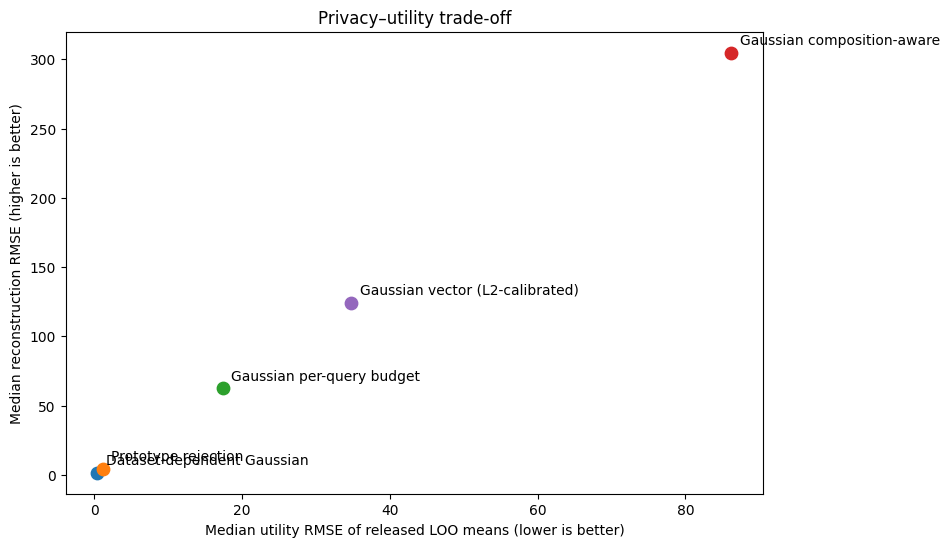

In [33]:
plt.figure(figsize=(9, 6))

for _, row in privacy_utility_df.iterrows():
    plt.scatter(
        row["median_utility_RMSE"],
        row["median_reconstruction_RMSE"],
        s=80,
    )

    plt.annotate(
        row["mechanism"],
        (
            row["median_utility_RMSE"],
            row["median_reconstruction_RMSE"],
        ),
        xytext=(6, 6),
        textcoords="offset points",
    )

plt.xlabel(
    "Median utility RMSE of released LOO means (lower is better)"
)

plt.ylabel(
    "Median reconstruction RMSE (higher is better)"
)

plt.title(
    "Privacy–utility trade-off"
)

plt.show()

### How to interpret the result

A mechanism with very high reconstruction RMSE is not automatically attractive.

If its utility RMSE is also enormous, the attack may fail mainly because the released statistic no longer resembles the quantity we wanted to publish.

Conversely, a mechanism with tiny utility error but tiny reconstruction error leaves the scientific statistic intact but also allows accurate reconstruction.

The interesting mechanisms are those that move toward the **upper-left** of the trade-off plot.

For the eventual neuroimaging method, the utility metric will not necessarily be LOO-mean RMSE. It may instead be something scientifically meaningful for the released covariance representation, such as:

- Frobenius error of the covariance matrix;
- correlation-matrix error;
- eigenvalue/eigenspace preservation;
- downstream prediction or inference accuracy.

The conceptual separation remains the same:

$$
\text{privacy / attack resistance}
\neq
\text{scientific utility}.
$$

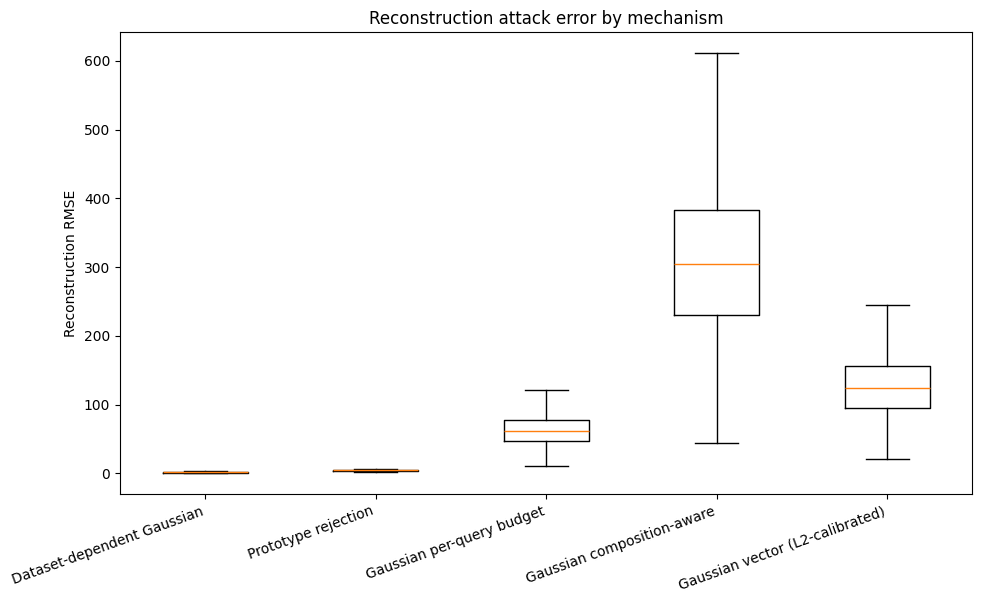

In [34]:
labels = []
rmse_arrays = []

for mechanism, result in (
    reconstruction_results_D.items()
):
    rmse = result["rmse_per_trial"]

    if len(rmse):
        labels.append(mechanism)
        rmse_arrays.append(rmse)

plt.figure(figsize=(11, 6))

plt.boxplot(
    rmse_arrays,
    tick_labels=labels,
    showfliers=False,
)

plt.ylabel("Reconstruction RMSE")
plt.title(
    "Reconstruction attack error by mechanism"
)

plt.xticks(
    rotation=20,
    ha="right",
)

plt.show()

### 13.6 One reconstructed dataset from each mechanism

The next plot shows one Monte Carlo trial.

The horizontal axis contains the true subject values. The vertical axis contains the values reconstructed by the attacker.

Perfect reconstruction would lie on the identity line

$$
\hat{x}_i=x_i.
$$

This visualization is useful because two mechanisms can have similar average RMSE while producing very different subject-level reconstruction patterns.

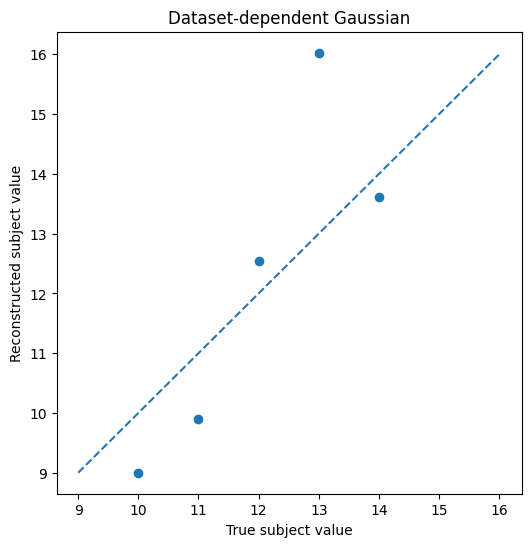

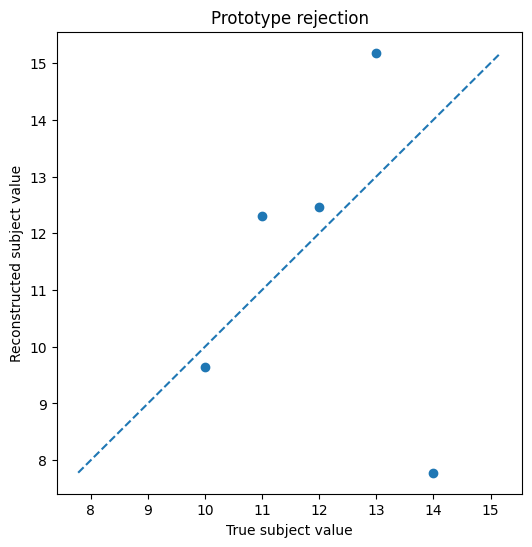

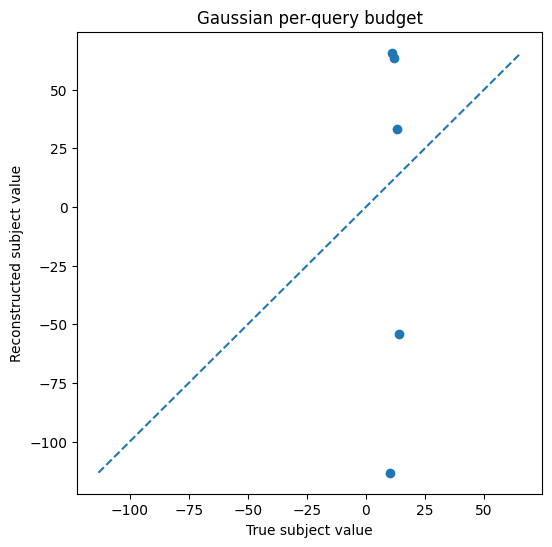

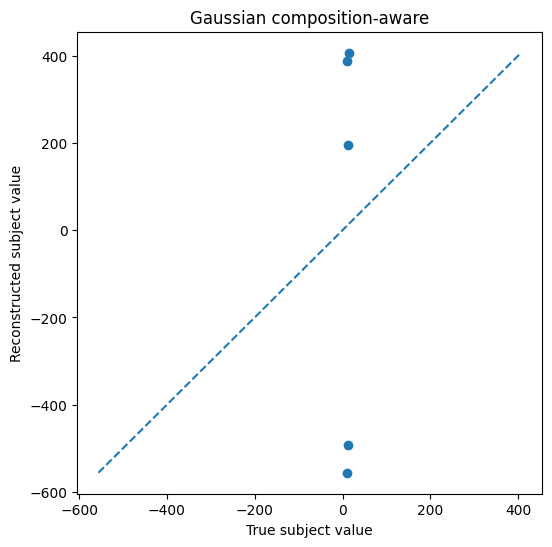

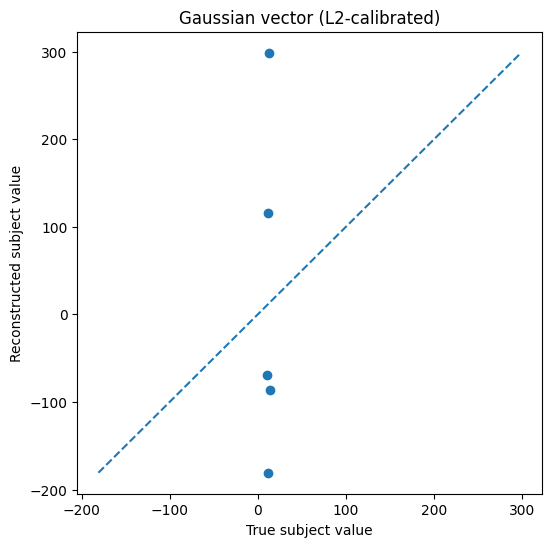

In [35]:
for mechanism, result in (
    reconstruction_results_D.items()
):
    reconstructed = result["reconstructed"]

    if len(reconstructed) == 0:
        continue

    example_reconstruction = (
        reconstructed[0]
    )

    plt.figure(figsize=(6, 6))

    plt.scatter(
        D,
        example_reconstruction,
    )

    identity_min = min(
        np.min(D),
        np.min(example_reconstruction),
    )

    identity_max = max(
        np.max(D),
        np.max(example_reconstruction),
    )

    plt.plot(
        [identity_min, identity_max],
        [identity_min, identity_max],
        linestyle="--",
    )

    plt.xlabel("True subject value")
    plt.ylabel("Reconstructed subject value")
    plt.title(mechanism)

    plt.show()

### 13.7 Why small LOO-mean noise can cause large reconstruction error

The attacker in this notebook does **not** know the full mean exactly. Instead, the attacker estimates it from all noisy LOO releases.

Write the noisy LOO release for subject $i$ as

$$
\widetilde{\bar{x}}_{-i}
=
\bar{x}_{-i}+\eta_i.
$$

The attacker estimates the full mean by averaging all released LOO means:

$$
\widetilde{\bar{x}}
=
\frac{1}{n}
\sum_{j=1}^{n}
\widetilde{\bar{x}}_{-j}.
$$

Because the average of the exact LOO means equals the true full mean,

$$
\widetilde{\bar{x}}
=
\bar{x}
+
\frac{1}{n}
\sum_{j=1}^{n}\eta_j.
$$

The reconstructed subject value is

$$
\hat{x}_i
=
n\widetilde{\bar{x}}
-
(n-1)\widetilde{\bar{x}}_{-i}.
$$

Substituting the noisy releases gives

$$
\hat{x}_i-x_i
=
\sum_{j\neq i}\eta_j
-
(n-2)\eta_i.
$$

So the reconstruction error combines noise from **all** released LOO means, and the subject's own LOO noise receives the coefficient $n-2$.

If the noise terms are independent with common variance $\sigma^2$, then

$$
\operatorname{Var}(\hat{x}_i-x_i)
=
\left[
(n-1)+(n-2)^2
\right]\sigma^2.
$$

This explains why noise that looks modest at the group-mean level can become much larger when an attacker algebraically reconstructs individual values.

### 13.8 What this experiment establishes — and what it does not

The reconstruction experiment now gives us a separate empirical privacy axis:

$$
\text{reconstruction error}.
$$

The earlier sections give us formal/privacy-distribution axes such as:

- privacy loss;
- support mismatch;
- lower bounds on $\delta$;
- calibrated Gaussian noise.

These should not be collapsed into one metric.

A mechanism can have:

- high reconstruction error but poor differential privacy;
- strong formal DP but poor statistical utility;
- or, ideally, useful reconstruction protection, formal privacy, and acceptable utility.

The composition-aware Gaussian row is particularly important. Releasing many LOO statistics consumes more privacy budget than releasing one statistic. Ignoring that composition can make a mechanism appear much more useful than it would be under a fixed total privacy budget.

### For the exact LOO inversion attack, formal Gaussian noise determines the reconstruction error

The exact LOO workload has an especially clean structure.

Write the raw data as

$$
x
$$

and the vector of all LOO means as

$$
v = Ax,
$$

where $A$ is invertible.

The formal Gaussian vector mechanism releases

$$
\widetilde v
=
Ax + z,
$$

with calibrated Gaussian noise $z$.

If the attacker performs the exact inverse transformation,

$$
\widehat x
=
A^{-1}\widetilde v,
$$

then

$$
\widehat x
=
x + A^{-1}z.
$$

Therefore

$$
\boxed{
\widehat x-x
=
A^{-1}z
}.
$$

For this specific attack, once the DP mechanism fixes the noise distribution, the reconstruction-error distribution follows algebraically. Reconstruction resistance is therefore not an independently tuned feature of the formal Gaussian mechanism.

This does **not** mean reconstruction error and differential privacy are the same concept in general.

Differential privacy constrains how distinguishable neighboring datasets are from the randomized output. Reconstruction error measures how accurately a particular estimator recovers a particular private target.

They coincide this closely here only because:

1. the released LOO vector is an invertible linear encoding of the scalar microdata;
2. the attacker uses the exact inverse transformation;
3. the mechanism adds known Gaussian noise to that vector.

The prototype is different. Its rejection rule was designed directly to frustrate reconstruction without first establishing a matching global DP guarantee. That is why it can appear to occupy a very attractive region of the privacy–utility plot while operating under a fundamentally different privacy condition.

## Systematic sweep over sample size and $\epsilon$

The toy example deliberately used a very small dataset, wide public bounds, and a strict privacy setting. The resulting formal Gaussian noise was therefore large.

We now test whether that poor utility is:

1. an intrinsic consequence of formal DP, or
2. largely a consequence of the specific setup, especially the release of **many LOO statistics**.

We vary two parameters:

$$
n \in \{5,10,20,50,100,200\}
$$

and

$$
\epsilon \in \{0.25,0.5,1.0\}.
$$

For every combination, several independently simulated datasets are generated.

Two situations are deliberately kept separate:

### A. One final aggregate release

Only the ordinary group mean is privatized once.

For a bounded mean,

$$
\Delta_{\mathrm{mean}}
=
\frac{U-L}{n}.
$$

As $n$ increases, sensitivity and therefore Gaussian noise should decrease approximately as $1/n$.

### B. Release all $n$ LOO means

This is the reconstruction-attack setting used earlier.

If the total privacy budget is kept fixed and split across all $n$ LOO releases, the gain from increasing $n$ can be largely cancelled by composition.

This distinction is important for the eventual neuroimaging project, because the intended central-DP method should release **one final aggregate representation**, not one public LOO statistic per subject.

### Sweep configuration

The defaults below are intentionally moderate so the notebook remains practical.

Increase `grid_repetitions` and `grid_reconstruction_draws` for more stable final experiments.

In [36]:
GRID_CONFIG = {
    "sample_sizes": [5, 10, 20, 50, 100, 200],
    "epsilons": [0.25, 0.5, 1.0],

    # Independent simulated datasets per (n, epsilon) cell.
    "grid_repetitions": 5,

    # Monte Carlo release sets per dataset for reconstruction/utility.
    "grid_reconstruction_draws": 500,

    # Monte Carlo draws used for prototype support diagnostics.
    "grid_support_draws": 2_000,

    # Base seed; each scenario gets a deterministic offset.
    "grid_seed": 2026,
}

### Why $n$ and $\epsilon$ are the first parameters to sweep

These two parameters have especially transparent effects on the Gaussian mechanism.

For one bounded mean,

$$
\Delta_{\mathrm{mean}}
=
\frac{U-L}{n},
$$

and the Gaussian noise scale used in this notebook is

$$
\sigma
=
\frac{
\Delta_{\mathrm{mean}}
\sqrt{2\ln(1.25/\delta)}
}{
\epsilon
}.
$$

So, with the clipping range and $\delta$ held fixed,

$$
\sigma
\propto
\frac{1}{n\epsilon}.
$$

This gives us two useful sanity checks:

- doubling $n$ should approximately halve the required noise;
- doubling $\epsilon$ should also approximately halve the required noise.

If the simulation does not show this behavior for the **single aggregate release**, that would indicate a coding or interpretation problem.

The LOO-release setting is more complicated because the number of releases also increases with $n$, so composition can counteract the sensitivity improvement.

### Metrics recorded

For the **single aggregate Gaussian release** we record:

- global sensitivity;
- formal Gaussian noise SD;
- expected utility RMSE.

Because zero-mean Gaussian noise has RMSE equal to its standard deviation,

$$
\operatorname{RMSE}_{\mathrm{utility}}
=
\sigma.
$$

For the **LOO reconstruction experiment** we record, for each mechanism:

- LOO utility RMSE: lower is better;
- reconstruction RMSE: higher is better;
- both values normalized by the public data range $U-L$;
- prototype support-induced lower bound on $\delta$.

The normalized errors make results easier to compare across different public ranges later.

### What the sweep holds constant

Across the grid, we vary only $n$ and $\epsilon$.

The following remain fixed unless `CONFIG` is changed:

- the public clipping bounds $[L,U]$;
- $\delta$;
- the simulated population mean and standard deviation;
- the neighboring-subject replacement value;
- the mechanism-specific multipliers.

This is important because it lets us attribute systematic changes primarily to $n$ and $\epsilon$.

Each simulated dataset is clipped to the same public bounds. Clipping is not only a numerical convenience: in a formal DP mechanism, those public bounds are what make the mean sensitivity finite.

The sweep therefore answers a deliberately narrow question:

> Under one fixed data-generating setup and one fixed clipping range, how do sample size and privacy strength alter utility and reconstruction resistance?

In [37]:
def summarize_reconstruction_utility(
    data,
    config,
):
    """
    Run the existing LOO reconstruction experiment and return one row
    per mechanism with both release utility and reconstruction error.
    """
    results, params = run_reconstruction_experiment(
        data,
        config,
    )

    exact_loo = params["loo_means"]
    public_range = (
        config["upper_bound"]
        - config["lower_bound"]
    )

    rows = []

    for mechanism, result in results.items():
        releases = result["releases"]
        reconstruction_rmse = result["rmse_per_trial"]

        if len(releases) == 0:
            utility_median = np.nan
            utility_mean = np.nan
        else:
            utility = release_utility_metrics(
                releases,
                exact_loo,
            )

            utility_median = np.median(
                utility["rmse_per_trial"]
            )

            utility_mean = np.mean(
                utility["rmse_per_trial"]
            )

        if len(reconstruction_rmse) == 0:
            reconstruction_median = np.nan
            reconstruction_mean = np.nan
        else:
            reconstruction_median = np.median(
                reconstruction_rmse
            )

            reconstruction_mean = np.mean(
                reconstruction_rmse
            )

        rows.append({
            "mechanism": mechanism,
            "valid_fraction": result["valid_fraction"],
            "median_utility_RMSE": utility_median,
            "mean_utility_RMSE": utility_mean,
            "median_reconstruction_RMSE": reconstruction_median,
            "mean_reconstruction_RMSE": reconstruction_mean,
            "median_utility_RMSE_normalized": (
                utility_median / public_range
            ),
            "median_reconstruction_RMSE_normalized": (
                reconstruction_median / public_range
            ),
        })

    return rows

### Two experiments are run inside every grid cell

For every $(n,\epsilon)$ combination, the code deliberately evaluates two different publication strategies.

#### Single aggregate release

The full dataset contributes to **one mean**, and that mean is released once with formally calibrated Gaussian noise.

This is closest to the structure we ultimately want:

$$
\text{subjects}
\rightarrow
\text{aggregate}
\rightarrow
\text{one DP release}.
$$

#### LOO release collection

The code also constructs and releases all leave-one-out means. These releases are then fed to the reconstruction attack.

This is intentionally a harder and less realistic publication strategy. It is useful because it creates the algebraic reconstruction vulnerability we want to study, but it should not be confused with the intended final central-DP design.

Keeping these two cases in the same sweep makes it possible to see how much of the utility loss comes from **DP calibration itself** and how much comes from **repeated publication plus composition**.

In [38]:
def run_n_epsilon_grid(
    base_config,
    grid_config,
):
    rows = []
    single_release_rows = []

    scenario_counter = 0

    for n in grid_config["sample_sizes"]:
        for epsilon in grid_config["epsilons"]:
            for repetition in range(
                grid_config["grid_repetitions"]
            ):
                scenario_counter += 1

                cfg = dict(base_config)

                # Use simulated data for sample-size sweeps.
                cfg["dataset_mode"] = "normal"
                cfg["n"] = int(n)
                cfg["epsilon"] = float(epsilon)

                # Keep the replacement at the last subject.
                cfg["neighbor_index"] = -1

                # Use a different but reproducible dataset for every repetition.
                cfg["seed"] = (
                    grid_config["grid_seed"]
                    + 10_000 * n
                    + 100 * int(round(epsilon * 100))
                    + repetition
                )

                cfg["reconstruction_draws"] = int(
                    grid_config[
                        "grid_reconstruction_draws"
                    ]
                )

                # ----------------------------------------------------------
                # Construct the current private dataset.
                # ----------------------------------------------------------
                data = build_dataset(cfg)

                neighbor, changed_index = make_neighbor(
                    data,
                    cfg["neighbor_index"],
                    cfg["neighbor_replacement"],
                )

                public_range = (
                    cfg["upper_bound"]
                    - cfg["lower_bound"]
                )

                # ----------------------------------------------------------
                # A. ONE final aggregate mean release.
                # ----------------------------------------------------------
                global_sens_mean = (
                    public_range / len(data)
                )

                single_mean_gaussian_sd = (
                    analytic_gaussian_dp_sd(
                        global_sens_mean,
                        cfg["epsilon"],
                        cfg["delta"],
                    )
                )

                mean_shift = abs(
                    np.mean(data)
                    - np.mean(neighbor)
                )

                single_pair_delta = gaussian_pair_delta(
                    mean_shift,
                    single_mean_gaussian_sd,
                    cfg["epsilon"],
                )

                single_release_rows.append({
                    "n": len(data),
                    "epsilon": cfg["epsilon"],
                    "repetition": repetition,
                    "global_sensitivity": global_sens_mean,
                    "gaussian_noise_sd": single_mean_gaussian_sd,
                    "utility_RMSE": single_mean_gaussian_sd,
                    "utility_RMSE_normalized": (
                        single_mean_gaussian_sd
                        / public_range
                    ),
                    "actual_neighbor_mean_shift": mean_shift,
                    "actual_pair_delta": single_pair_delta,
                })

                # ----------------------------------------------------------
                # B. MANY LOO releases + reconstruction attack.
                # ----------------------------------------------------------
                mechanism_rows = (
                    summarize_reconstruction_utility(
                        data,
                        cfg,
                    )
                )

                # Prototype support diagnostic from the existing scenario runner.
                support_cfg = dict(cfg)
                support_cfg["sweep_draws"] = int(
                    grid_config["grid_support_draws"]
                )

                support_result = run_scenario(
                    support_cfg,
                    n_draws=grid_config[
                        "grid_support_draws"
                    ],
                )

                support_delta_lower_bound = max(
                    support_result[
                        "exclusive_rejection_prob_D"
                    ],
                    support_result[
                        "exclusive_rejection_prob_neighbor"
                    ],
                )

                for mechanism_row in mechanism_rows:
                    rows.append({
                        "n": len(data),
                        "epsilon": cfg["epsilon"],
                        "repetition": repetition,
                        "mechanism": mechanism_row[
                            "mechanism"
                        ],
                        "valid_fraction": mechanism_row[
                            "valid_fraction"
                        ],
                        "median_utility_RMSE": mechanism_row[
                            "median_utility_RMSE"
                        ],
                        "mean_utility_RMSE": mechanism_row[
                            "mean_utility_RMSE"
                        ],
                        "median_reconstruction_RMSE": mechanism_row[
                            "median_reconstruction_RMSE"
                        ],
                        "mean_reconstruction_RMSE": mechanism_row[
                            "mean_reconstruction_RMSE"
                        ],
                        "median_utility_RMSE_normalized": mechanism_row[
                            "median_utility_RMSE_normalized"
                        ],
                        "median_reconstruction_RMSE_normalized": mechanism_row[
                            "median_reconstruction_RMSE_normalized"
                        ],
                        "prototype_support_delta_lower_bound": (
                            support_delta_lower_bound
                        ),
                    })

    return (
        pd.DataFrame(single_release_rows),
        pd.DataFrame(rows),
    )

### Run the grid

This can take a few minutes depending on the number of repetitions and Monte Carlo draws.

For exploratory work, the defaults are sufficient. For final results, increase the repetition count rather than relying on one random dataset per parameter combination.

In [39]:
single_release_grid_df, loo_grid_df = (
    run_n_epsilon_grid(
        CONFIG,
        GRID_CONFIG,
    )
)

print(
    "Single-release scenarios:",
    len(single_release_grid_df),
)

print(
    "LOO mechanism rows:",
    len(loo_grid_df),
)

Single-release scenarios: 90
LOO mechanism rows: 450


### Monte Carlo interpretation

The grid is stochastic in two ways:

1. new synthetic datasets are generated for each repetition;
2. each privacy mechanism produces randomized releases.

The current defaults are intended for exploration rather than final inference.

With only a few repetitions per grid cell, individual points can fluctuate because of random dataset composition and random mechanism noise. The main quantities to trust at this stage are broad patterns such as:

- whether curves decrease with $n$;
- whether changing $\epsilon$ has the expected direction;
- whether one mechanism remains orders of magnitude larger than another.

For publication-quality simulation results, we would later increase the number of dataset repetitions and report uncertainty intervals across repetitions.

## Sweep result A: one final aggregate release

This is the setting most similar to the intended central-DP design.

Because there is only one release, there is no $n$-fold LOO composition penalty.

We first average across independently generated datasets for each $(n,\epsilon)$ combination.

In [40]:
single_summary = (
    single_release_grid_df
    .groupby(
        ["n", "epsilon"],
        as_index=False,
    )
    .agg(
        mean_global_sensitivity=(
            "global_sensitivity",
            "mean",
        ),
        mean_gaussian_noise_sd=(
            "gaussian_noise_sd",
            "mean",
        ),
        mean_utility_RMSE=(
            "utility_RMSE",
            "mean",
        ),
        mean_normalized_utility_RMSE=(
            "utility_RMSE_normalized",
            "mean",
        ),
        mean_actual_pair_delta=(
            "actual_pair_delta",
            "mean",
        ),
    )
)

single_summary

,n,epsilon,mean_global_sensitivity,mean_gaussian_noise_sd,mean_utility_RMSE,mean_normalized_utility_RMSE,mean_actual_pair_delta
0,5,0.25,4.0,53.142101,53.142101,2.657105,2.490432e-09
1,5,0.50,4.0,28.127307,28.127307,1.406365,1.971286e-20
2,5,1.00,4.0,14.922527,14.922527,0.746126,3.118120e-15
3,10,0.25,2.0,26.571050,26.571050,1.328553,7.501357e-15
4,10,0.50,2.0,14.063653,14.063653,0.703183,4.125854e-14
5,10,1.00,2.0,7.461263,7.461263,0.373063,3.973021e-13
6,20,0.25,1.0,13.285525,13.285525,0.664276,1.205494e-13
7,20,0.50,1.0,7.031827,7.031827,0.351591,7.768279e-12
8,20,1.00,1.0,3.730632,3.730632,0.186532,3.847548e-12
9,50,0.25,0.4,5.314210,5.314210,0.265711,2.052978e-13


### How to read the single-release table

For the single Gaussian release, `utility_RMSE` is numerically equal to the Gaussian noise standard deviation:

$$
\operatorname{RMSE}
=
\sqrt{E[Z^2]}
=
\sigma
\qquad
\text{for }
Z\sim\mathcal{N}(0,\sigma^2).
$$

So this table gives a direct measure of how much a published group mean is expected to move because of privacy noise.

The normalized utility RMSE divides this error by the public range:

$$
\text{normalized RMSE}
=
\frac{\text{RMSE}}{U-L}.
$$

This does not decide whether utility is scientifically acceptable by itself. It simply makes the distortion dimensionless and therefore easier to compare across future experiments with different measurement scales.

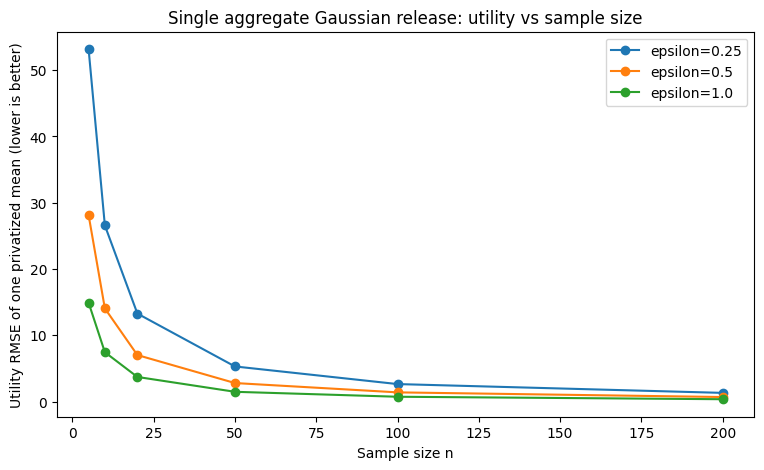

In [41]:
plt.figure(figsize=(9, 5))

for epsilon_value in sorted(
    single_summary["epsilon"].unique()
):
    subset = single_summary[
        single_summary["epsilon"]
        == epsilon_value
    ]

    plt.plot(
        subset["n"],
        subset["mean_utility_RMSE"],
        marker="o",
        label=f"epsilon={epsilon_value}",
    )

plt.xlabel("Sample size n")
plt.ylabel(
    "Utility RMSE of one privatized mean (lower is better)"
)
plt.title(
    "Single aggregate Gaussian release: utility vs sample size"
)
plt.legend()
plt.show()

### Interpreting the single-aggregate curves

This plot is the cleanest test of the formal central-DP mechanism.

If the curves approximately follow

$$
\frac{1}{n\epsilon},
$$

then the simulation is reproducing the theoretical sensitivity scaling.

The key point is that **larger datasets help twice conceptually**:

- each individual subject has less influence on the population mean;
- therefore less privacy noise is needed for the same $\epsilon,\delta$ target.

This is very different from the LOO publication experiment below, where increasing the number of subjects also increases the number of released statistics.

For the eventual covariance method, this single-release behavior is the more relevant conceptual model.

### Expected pattern

For one bounded mean,

$$
\sigma
\propto
\frac{U-L}{n\epsilon}.
$$

Therefore:

- larger $n$ should improve utility;
- larger $\epsilon$ should improve utility;
- narrower clipping bounds should improve utility.

If this plot improves strongly with $n$, then the enormous utility errors seen earlier are **not intrinsic to Gaussian DP itself**. They are at least partly caused by the much harder task of releasing all LOO means.

## Sweep result B: release all LOO means

Now summarize the setting required by the reconstruction attack.

This is a fundamentally harder privacy problem because many related statistics are released from the same subjects.

In [42]:
loo_summary = (
    loo_grid_df
    .groupby(
        ["n", "epsilon", "mechanism"],
        as_index=False,
    )
    .agg(
        mean_valid_fraction=(
            "valid_fraction",
            "mean",
        ),
        median_utility_RMSE=(
            "median_utility_RMSE",
            "median",
        ),
        median_reconstruction_RMSE=(
            "median_reconstruction_RMSE",
            "median",
        ),
        median_normalized_utility_RMSE=(
            "median_utility_RMSE_normalized",
            "median",
        ),
        median_normalized_reconstruction_RMSE=(
            "median_reconstruction_RMSE_normalized",
            "median",
        ),
        median_support_delta_lower_bound=(
            "prototype_support_delta_lower_bound",
            "median",
        ),
    )
)

loo_summary.head(20)

,n,epsilon,mechanism,mean_valid_fraction,median_utility_RMSE,median_reconstruction_RMSE,median_normalized_utility_RMSE,median_normalized_reconstruction_RMSE,median_support_delta_lower_bound
0,5,0.25,Dataset-dependent Gaussian,1.0,1.716247,6.062270,0.085812,0.303114,0.499
1,5,0.25,Gaussian composition-aware,1.0,300.297152,1061.860126,15.014858,53.093006,0.499
2,5,0.25,Gaussian per-query budget,1.0,62.127054,221.382956,3.106353,11.069148,0.499
3,5,0.25,Gaussian vector (L2-calibrated),1.0,123.470007,435.418034,6.173500,21.770902,0.499
4,5,0.25,Prototype rejection,1.0,1.295701,4.720065,0.064785,0.236003,0.499
5,5,0.50,Dataset-dependent Gaussian,1.0,0.921773,3.295788,0.046089,0.164789,0.497
6,5,0.50,Gaussian composition-aware,1.0,162.001428,571.740921,8.100071,28.587046,0.497
7,5,0.50,Gaussian per-query budget,1.0,32.584738,114.505838,1.629237,5.725292,0.497
8,5,0.50,Gaussian vector (L2-calibrated),1.0,66.402483,232.638025,3.320124,11.631901,0.497
9,5,0.50,Prototype rejection,1.0,1.410568,5.177026,0.070528,0.258851,0.497


In [43]:
def mechanism_privacy_status(row, target_delta):
    mechanism = row["mechanism"]

    if mechanism == "Gaussian vector (L2-calibrated)":
        return pd.Series({
            "privacy_class": "formal matched privacy",
            "epsilon_target": row["epsilon"],
            "delta_target": target_delta,
            "privacy_note": "One joint Gaussian vector mechanism",
        })

    if mechanism == "Gaussian composition-aware":
        return pd.Series({
            "privacy_class": "formal matched privacy",
            "epsilon_target": row["epsilon"],
            "delta_target": target_delta,
            "privacy_note": "Basic composition; conservative",
        })

    if mechanism == "Gaussian per-query budget":
        return pd.Series({
            "privacy_class": "not matched globally",
            "epsilon_target": np.nan,
            "delta_target": np.nan,
            "privacy_note": "Each coordinate gets full budget; total collection costs more",
        })

    if mechanism == "Prototype rejection":
        return pd.Series({
            "privacy_class": "empirical / no formal guarantee",
            "epsilon_target": np.nan,
            "delta_target": np.nan,
            "privacy_note": "Support lower bound on delta is only a diagnostic",
        })

    return pd.Series({
        "privacy_class": "empirical / no formal guarantee",
        "epsilon_target": np.nan,
        "delta_target": np.nan,
        "privacy_note": "Dataset-dependent calibration",
    })


privacy_status = loo_summary.apply(
    mechanism_privacy_status,
    axis=1,
    target_delta=CONFIG["delta"],
)

loo_summary = pd.concat(
    [
        loo_summary.reset_index(drop=True),
        privacy_status.reset_index(drop=True),
    ],
    axis=1,
)

loo_summary.head(20)

,n,epsilon,mechanism,mean_valid_fraction,median_utility_RMSE,median_reconstruction_RMSE,median_normalized_utility_RMSE,median_normalized_reconstruction_RMSE,median_support_delta_lower_bound,privacy_class,epsilon_target,delta_target,privacy_note
0,5,0.25,Dataset-dependent Gaussian,1.0,1.716247,6.062270,0.085812,0.303114,0.499,empirical / no formal guarantee,NaN,NaN,Dataset-dependent calibration
1,5,0.25,Gaussian composition-aware,1.0,300.297152,1061.860126,15.014858,53.093006,0.499,formal matched privacy,0.25,0.00001,Basic composition; conservative
2,5,0.25,Gaussian per-query budget,1.0,62.127054,221.382956,3.106353,11.069148,0.499,not matched globally,NaN,NaN,Each coordinate gets full budget; total collec...
3,5,0.25,Gaussian vector (L2-calibrated),1.0,123.470007,435.418034,6.173500,21.770902,0.499,formal matched privacy,0.25,0.00001,One joint Gaussian vector mechanism
4,5,0.25,Prototype rejection,1.0,1.295701,4.720065,0.064785,0.236003,0.499,empirical / no formal guarantee,NaN,NaN,Support lower bound on delta is only a diagnostic
5,5,0.50,Dataset-dependent Gaussian,1.0,0.921773,3.295788,0.046089,0.164789,0.497,empirical / no formal guarantee,NaN,NaN,Dataset-dependent calibration
6,5,0.50,Gaussian composition-aware,1.0,162.001428,571.740921,8.100071,28.587046,0.497,formal matched privacy,0.50,0.00001,Basic composition; conservative
7,5,0.50,Gaussian per-query budget,1.0,32.584738,114.505838,1.629237,5.725292,0.497,not matched globally,NaN,NaN,Each coordinate gets full budget; total collec...
8,5,0.50,Gaussian vector (L2-calibrated),1.0,66.402483,232.638025,3.320124,11.631901,0.497,formal matched privacy,0.50,0.00001,One joint Gaussian vector mechanism
9,5,0.50,Prototype rejection,1.0,1.410568,5.177026,0.070528,0.258851,0.497,empirical / no formal guarantee,NaN,NaN,Support lower bound on delta is only a diagnostic


### What each LOO mechanism represents

The mechanisms in the following plots should not be treated as four equally valid DP methods.

**Dataset-dependent Gaussian**

The noise width is estimated from private LOO behavior. This is useful as an empirical diagnostic, but the calibration itself is data-dependent and does not provide the formal guarantee of the Gaussian mechanism.

**Prototype rejection**

Noise is forced outside a dataset-specific sensitivity interval. This is designed to frustrate reconstruction and can preserve good utility, but the earlier privacy-loss analysis showed that the resulting support mismatch can require a very large $\delta$.

In this simplified prototype, $\epsilon$ does not control the rejection rule. Therefore the prototype curves may change little when $\epsilon$ changes. That is expected and is itself evidence that $\epsilon$ is not functioning as a formal privacy parameter for this mechanism.

**Gaussian per-query budget**

Every LOO release receives the full configured $(\epsilon,\delta)$ budget. This often looks attractive in utility terms, but the total privacy cost grows across releases.

**Gaussian composition-aware**

The configured privacy budget is split across all LOO releases using simple composition. This is the fairer formal-DP comparison when the entire collection must fit inside one fixed total budget, but it can require extremely large noise.

### Utility error across $n$ and $\epsilon$

Each mechanism is plotted separately so the scale of one method does not hide the others.

Lower curves are better.

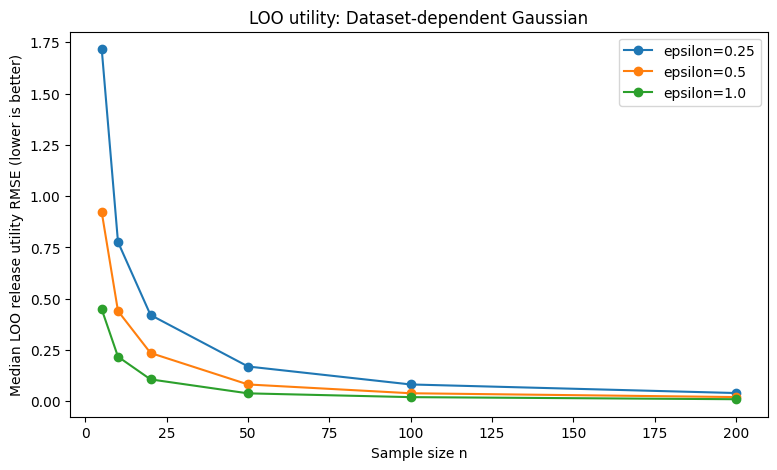

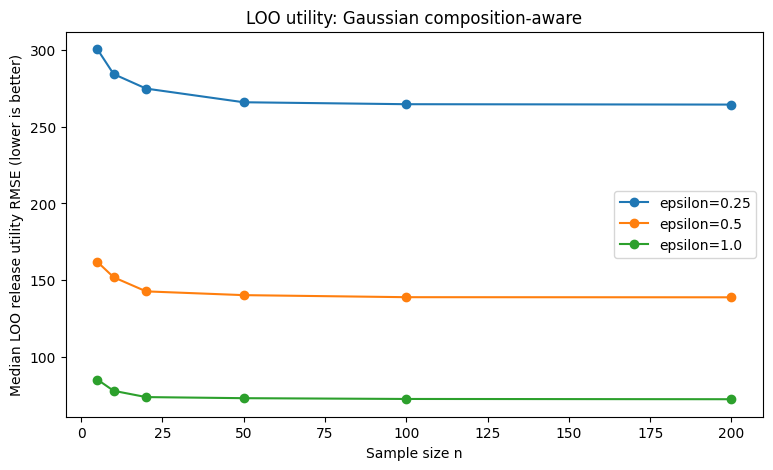

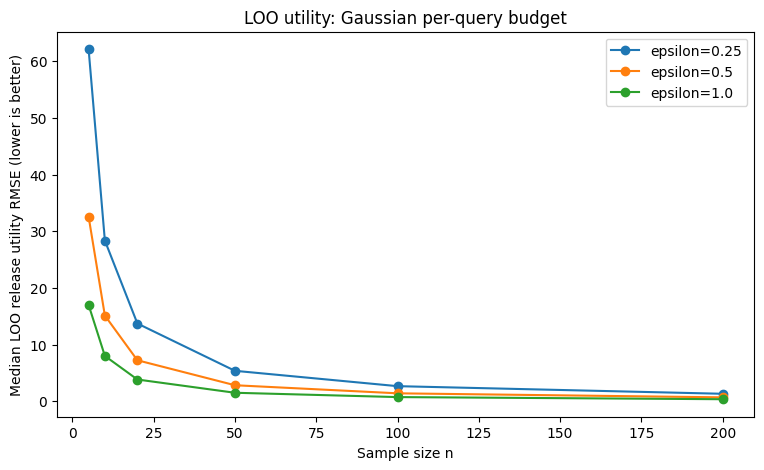

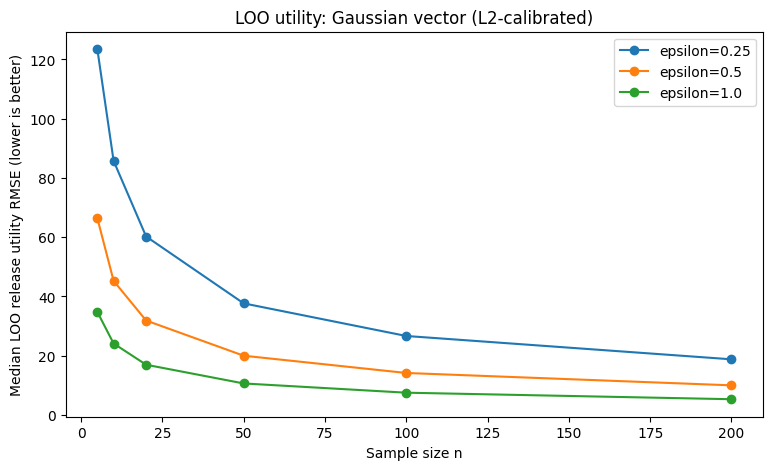

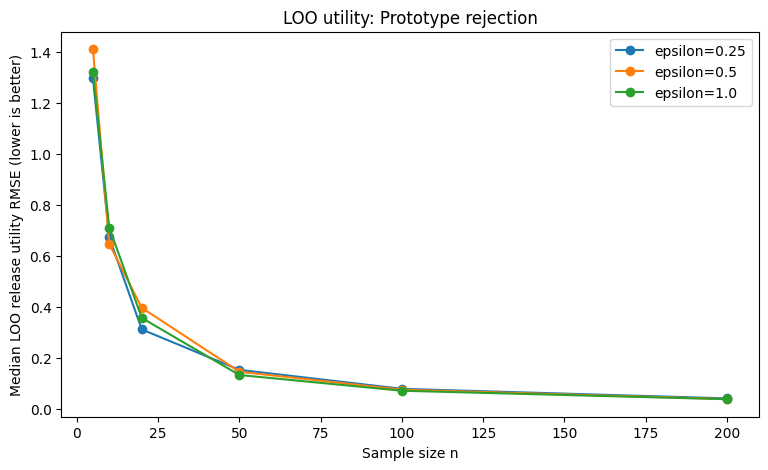

In [44]:
for mechanism in loo_summary[
    "mechanism"
].unique():
    subset_mechanism = loo_summary[
        loo_summary["mechanism"]
        == mechanism
    ]

    plt.figure(figsize=(9, 5))

    for epsilon_value in sorted(
        subset_mechanism[
            "epsilon"
        ].unique()
    ):
        subset = subset_mechanism[
            subset_mechanism["epsilon"]
            == epsilon_value
        ]

        plt.plot(
            subset["n"],
            subset["median_utility_RMSE"],
            marker="o",
            label=f"epsilon={epsilon_value}",
        )

    plt.xlabel("Sample size n")
    plt.ylabel(
        "Median LOO release utility RMSE (lower is better)"
    )
    plt.title(
        f"LOO utility: {mechanism}"
    )
    plt.legend()
    plt.show()

### Utility alone is not enough to validate a mechanism

A low LOO utility RMSE means that the noisy LOO means remain numerically close to their exact values.

That is desirable scientifically, but it says nothing by itself about whether the privacy guarantee is valid.

For example, the prototype rejection mechanism may achieve very low utility error because it perturbs the statistic only modestly. Yet its dataset-dependent forbidden output regions can still make neighboring datasets distinguishable.

So when a mechanism looks especially good in these utility plots, the correct follow-up question is:

> Does it achieve this utility under the same formal privacy guarantee as the mechanism we are comparing it with?

If not, the result is still scientifically interesting, but it is not a like-for-like DP comparison.

### Reconstruction error across $n$ and $\epsilon$

Higher curves mean the attacker reconstructs subjects less accurately.

This should always be interpreted together with the utility plot above.

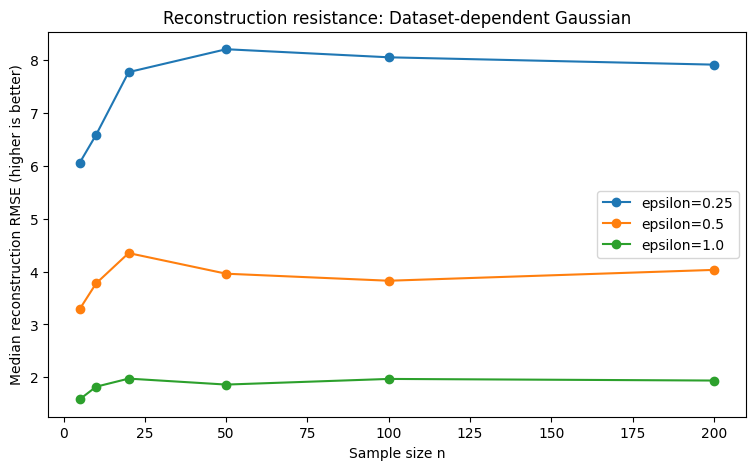

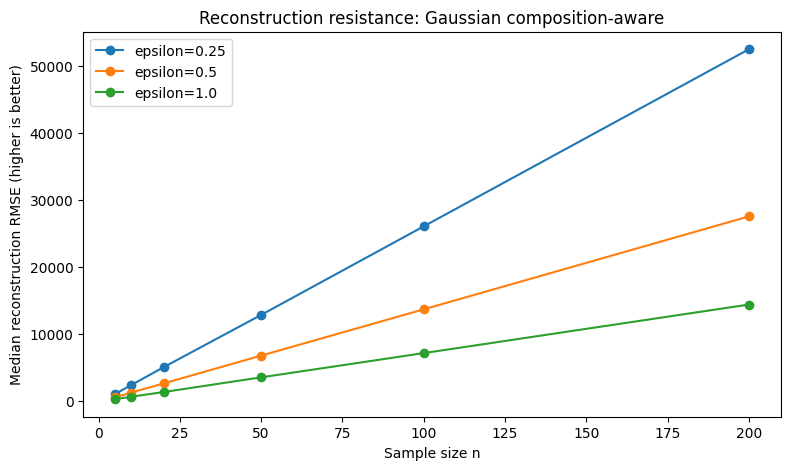

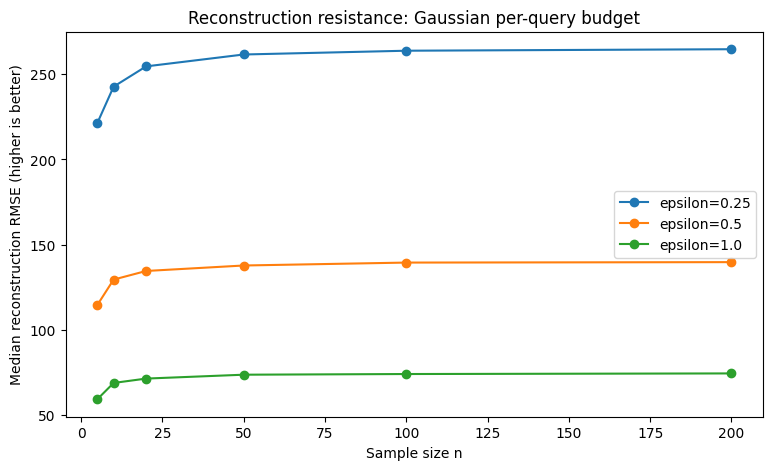

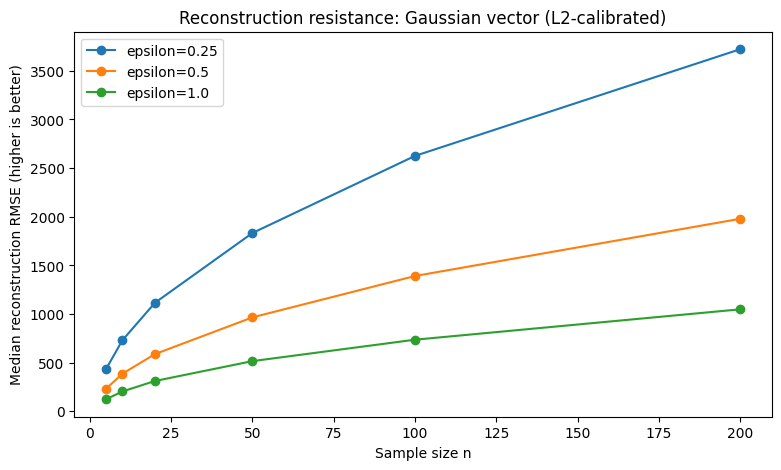

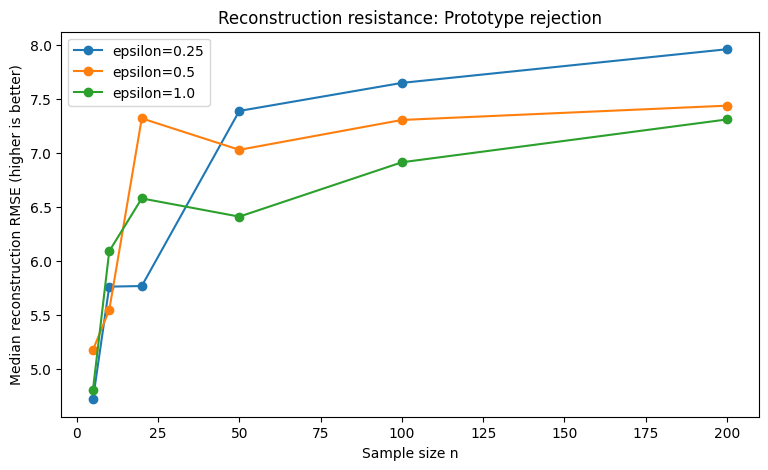

In [45]:
for mechanism in loo_summary[
    "mechanism"
].unique():
    subset_mechanism = loo_summary[
        loo_summary["mechanism"]
        == mechanism
    ]

    plt.figure(figsize=(9, 5))

    for epsilon_value in sorted(
        subset_mechanism[
            "epsilon"
        ].unique()
    ):
        subset = subset_mechanism[
            subset_mechanism["epsilon"]
            == epsilon_value
        ]

        plt.plot(
            subset["n"],
            subset["median_reconstruction_RMSE"],
            marker="o",
            label=f"epsilon={epsilon_value}",
        )

    plt.xlabel("Sample size n")
    plt.ylabel(
        "Median reconstruction RMSE (higher is better)"
    )
    plt.title(
        f"Reconstruction resistance: {mechanism}"
    )
    plt.legend()
    plt.show()

### Why reconstruction error can stay high as utility improves

At first this may seem counterintuitive:

> How can the released LOO means become increasingly accurate while reconstruction of individuals remains poor?

The reason is the reconstruction formula.

The attacker combines all noisy LOO releases, and the individual-level reconstruction error contains coefficients that grow with $n$:

$$
\hat{x}_i-x_i
=
\sum_{j\neq i}\eta_j
-
(n-2)\eta_i.
$$

So even if the noise on each LOO mean becomes smaller as the sample size grows, the algebraic inversion can amplify that noise when translating group-level quantities back into individual values.

This is exactly why reconstruction RMSE and release-utility RMSE are useful as **separate axes** rather than interchangeable privacy metrics.

## Matched-privacy comparison

A privacy–utility frontier is only fair when the compared mechanisms operate under the same privacy requirement.

The two mechanisms below both target the configured **total**

$$
(\epsilon,\delta)
$$

for the complete collection of LOO releases:

- **Gaussian composition-aware**: split the budget across releases using basic composition;
- **Gaussian vector (L2-calibrated)**: treat all LOO means as one vector query and calibrate directly to its joint $L_2$ sensitivity.

The second mechanism should dominate basic composition in utility because it uses the redundancy of the workload rather than ignoring it.

The prototype rejection and dataset-dependent Gaussian remain useful empirical references, but they are not placed on the same formal frontier because no matching global DP guarantee has been established for them.

### Why the basic-composition mechanism remains in the notebook

Once the joint LOO-vector mechanism is available, the basic-composition Gaussian is no longer a serious candidate for this workload.

It remains useful for one reason: it shows how much utility can be lost when a highly redundant vector query is broken into many separate releases and each release is privacy-accounted independently.

So the comparison

$$
\text{basic composition}
\quad\text{vs.}\quad
\text{joint vector mechanism}
$$

is primarily pedagogical.

The joint-vector mechanism is the appropriate formal baseline because it exploits the actual geometry of the complete query while satisfying the same total target

$$
(\epsilon,\delta).
$$

This lesson transfers directly to covariance: we should derive sensitivity for the **whole matrix/vector-valued release**, rather than privatizing covariance entries one at a time and composing them.

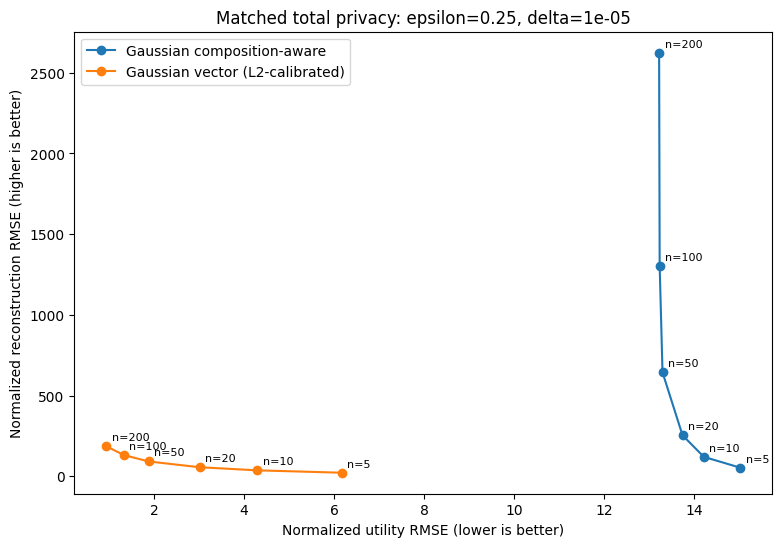

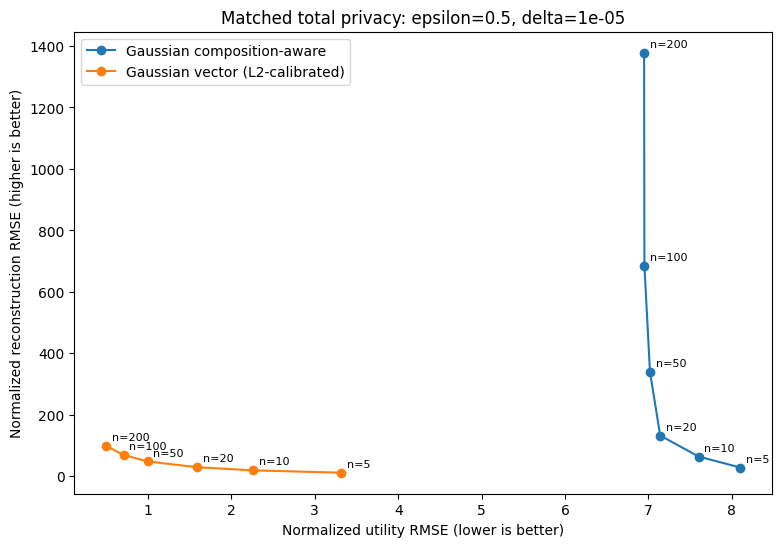

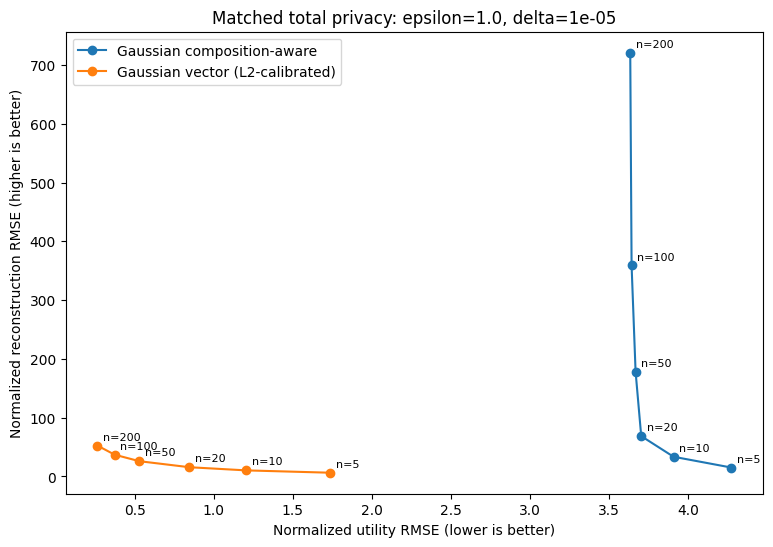

In [46]:
matched_privacy_mechanisms = [
    "Gaussian composition-aware",
    "Gaussian vector (L2-calibrated)",
]

matched_privacy_frontier = loo_summary[
    loo_summary["mechanism"].isin(
        matched_privacy_mechanisms
    )
].copy()

for epsilon_value in sorted(
    matched_privacy_frontier[
        "epsilon"
    ].unique()
):
    subset = matched_privacy_frontier[
        matched_privacy_frontier["epsilon"]
        == epsilon_value
    ]

    plt.figure(figsize=(9, 6))

    for mechanism in matched_privacy_mechanisms:
        mechanism_subset = subset[
            subset["mechanism"]
            == mechanism
        ]

        plt.plot(
            mechanism_subset[
                "median_normalized_utility_RMSE"
            ],
            mechanism_subset[
                "median_normalized_reconstruction_RMSE"
            ],
            marker="o",
            label=mechanism,
        )

        for _, row in mechanism_subset.iterrows():
            plt.annotate(
                f"n={int(row['n'])}",
                (
                    row[
                        "median_normalized_utility_RMSE"
                    ],
                    row[
                        "median_normalized_reconstruction_RMSE"
                    ],
                ),
                xytext=(4, 4),
                textcoords="offset points",
                fontsize=8,
            )

    plt.xlabel(
        "Normalized utility RMSE (lower is better)"
    )
    plt.ylabel(
        "Normalized reconstruction RMSE (higher is better)"
    )
    plt.title(
        f"Matched total privacy: epsilon={epsilon_value}, "
        f"delta={CONFIG['delta']}"
    )
    plt.legend()
    plt.show()
    plt.close()

## Privacy–utility frontier across the entire grid

For this plot:

- horizontal axis = normalized utility error, so **left is better**;
- vertical axis = normalized reconstruction error, so **up is better**.

The preferred direction is therefore the **upper-left**.

Normalization by the public range makes the axes dimensionless:

$$
\text{normalized error}
=
\frac{\text{RMSE}}{U-L}.
$$

The point labels show $(n,\epsilon)$.

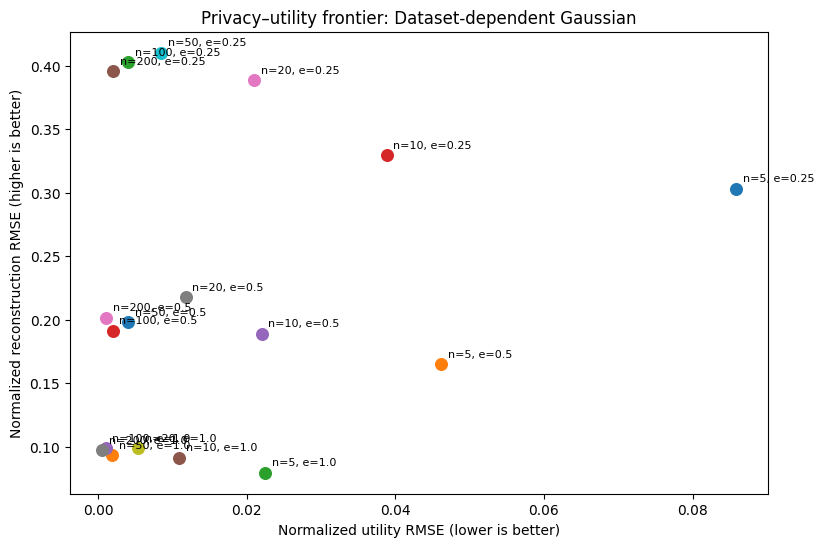

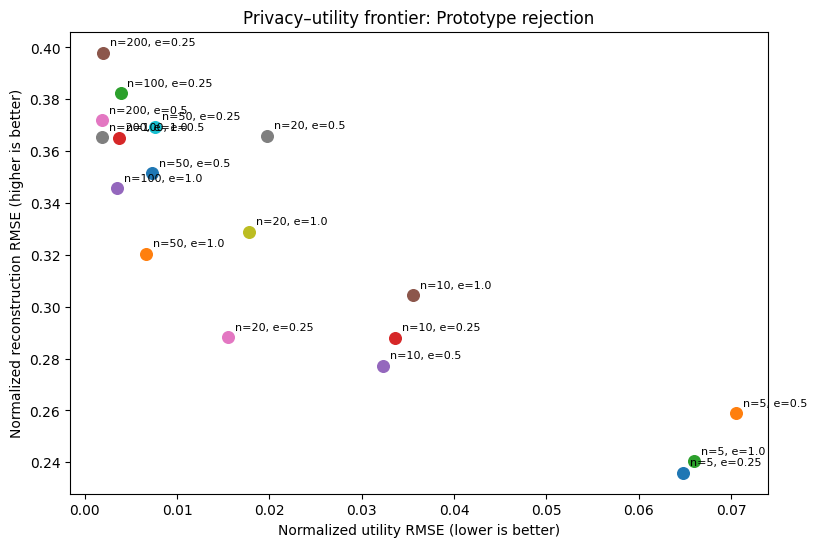

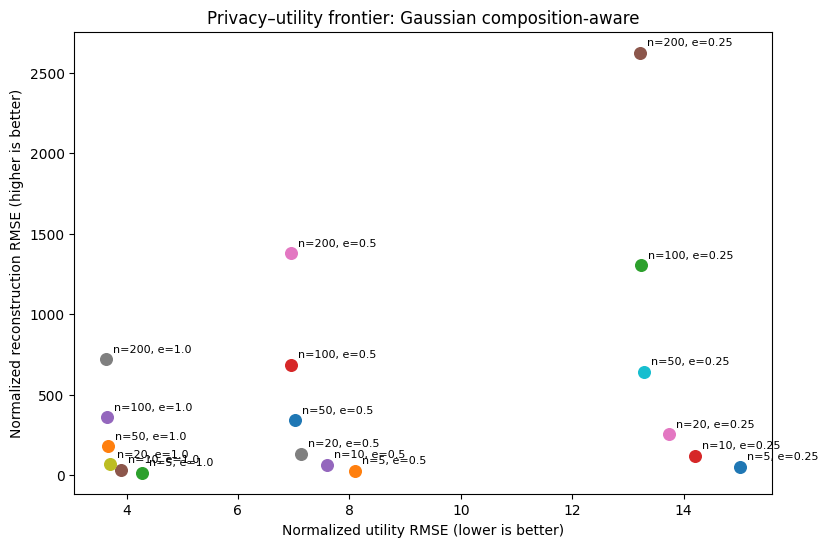

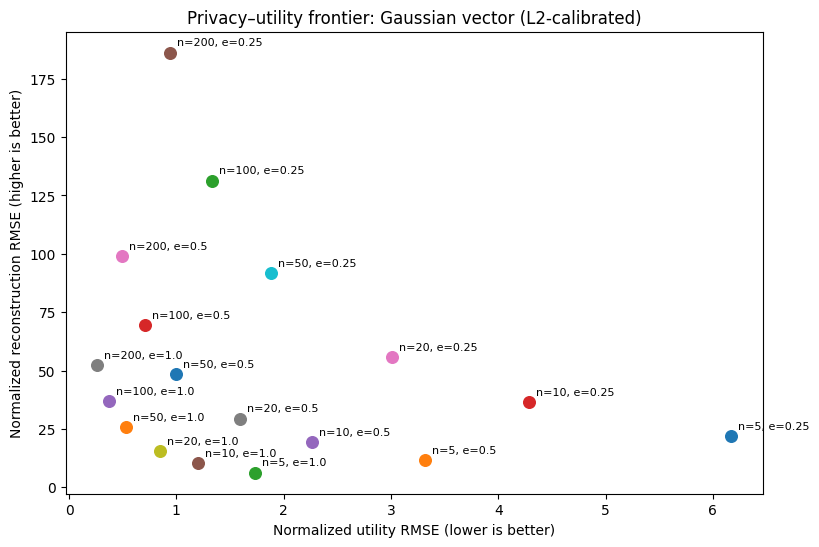

In [47]:
MECHANISMS_FOR_FRONTIER = [
    "Dataset-dependent Gaussian",
    "Prototype rejection",
    "Gaussian composition-aware",
    "Gaussian vector (L2-calibrated)",
]

for mechanism in MECHANISMS_FOR_FRONTIER:
    subset = loo_summary[
        loo_summary["mechanism"]
        == mechanism
    ]

    if len(subset) == 0:
        continue

    plt.figure(figsize=(9, 6))

    for _, row in subset.iterrows():
        x = row[
            "median_normalized_utility_RMSE"
        ]

        y = row[
            "median_normalized_reconstruction_RMSE"
        ]

        plt.scatter(
            x,
            y,
            s=70,
        )

        plt.annotate(
            f"n={int(row['n'])}, e={row['epsilon']}",
            (x, y),
            xytext=(5, 5),
            textcoords="offset points",
            fontsize=8,
        )

    plt.xlabel(
        "Normalized utility RMSE (lower is better)"
    )
    plt.ylabel(
        "Normalized reconstruction RMSE (higher is better)"
    )
    plt.title(
        f"Privacy–utility frontier: {mechanism}"
    )
    plt.show()

### The frontier is descriptive, not a single score

The upper-left direction is visually attractive:

- low utility error;
- high reconstruction error.

But there is no universal distance-to-the-upper-left score that determines the best mechanism.

A useful mechanism must satisfy several separate conditions:

1. the privacy guarantee must be valid;
2. utility must be acceptable for the intended scientific task;
3. reconstruction resistance should be evaluated against plausible attacks.

A mechanism with excellent coordinates in this plot can still fail condition 1. Conversely, a formally private mechanism can sit far to the right because its current clipping range or privacy parameters are too conservative.

Later, for covariance data, we will replace generic mean RMSE with utility measures that reflect the actual scientific object being released.

## Compare the fair formal mechanism with the prototype

The most important LOO comparison is:

- **Prototype rejection**: empirically designed to frustrate reconstruction, but without a formal DP guarantee;
- **Gaussian composition-aware**: keeps the total privacy budget fixed across all LOO releases using simple composition.

The next table places them side by side.

In [48]:
comparison_mechanisms = [
    "Prototype rejection",
    "Gaussian composition-aware",
    "Gaussian vector (L2-calibrated)",
]

comparison_grid = loo_summary[
    loo_summary["mechanism"].isin(
        comparison_mechanisms
    )
][
    [
        "n",
        "epsilon",
        "mechanism",
        "median_utility_RMSE",
        "median_reconstruction_RMSE",
        "median_normalized_utility_RMSE",
        "median_normalized_reconstruction_RMSE",
        "median_support_delta_lower_bound",
    ]
].sort_values(
    ["n", "epsilon", "mechanism"]
)

comparison_grid

,n,epsilon,mechanism,median_utility_RMSE,median_reconstruction_RMSE,median_normalized_utility_RMSE,median_normalized_reconstruction_RMSE,median_support_delta_lower_bound
1,5,0.25,Gaussian composition-aware,300.297152,1061.860126,15.014858,53.093006,0.4990
3,5,0.25,Gaussian vector (L2-calibrated),123.470007,435.418034,6.173500,21.770902,0.4990
4,5,0.25,Prototype rejection,1.295701,4.720065,0.064785,0.236003,0.4990
6,5,0.50,Gaussian composition-aware,162.001428,571.740921,8.100071,28.587046,0.4970
8,5,0.50,Gaussian vector (L2-calibrated),66.402483,232.638025,3.320124,11.631901,0.4970
9,5,0.50,Prototype rejection,1.410568,5.177026,0.070528,0.258851,0.4970
11,5,1.00,Gaussian composition-aware,85.477421,300.621401,4.273871,15.031070,0.4990
13,5,1.00,Gaussian vector (L2-calibrated),34.746942,125.010060,1.737347,6.250503,0.4990
14,5,1.00,Prototype rejection,1.319431,4.809420,0.065972,0.240471,0.4990
16,10,0.25,Gaussian composition-aware,284.152204,2400.937187,14.207610,120.046859,0.4970


### Why this comparison is intentionally asymmetric

The prototype and the composition-aware Gaussian mechanism are answering related but different questions.

The prototype asks:

> Can modest, structured perturbation frustrate this reconstruction attack while keeping the released statistics accurate?

The composition-aware Gaussian mechanism asks:

> How much noise is required if all LOO releases together must obey one fixed formal privacy budget under simple composition?

Therefore a result where the prototype has much better utility does not mean that formal DP is intrinsically inefficient. It means that the prototype is operating under a weaker privacy requirement.

Likewise, the enormous reconstruction error of the composition-aware mechanism is not automatically a success: if its utility error is also enormous, the attack fails largely because the released data have been made unusable.

The purpose of this table is to expose that distinction explicitly.

## Important limitations of this sweep

Before drawing conclusions from the plots, several limitations should remain visible.

### The released statistic is only a scalar mean

The final project concerns multivariate covariance information. Mean sensitivity is analytically simple, while covariance sensitivity depends on the chosen subject-level representation and clipping rule.

### The data are synthetic and one-dimensional

The current normal-data generator is intentionally simple. It does not reproduce the dependence structure, heterogeneity, temporal structure, or dimensionality of fMRI data.

### The reconstruction attack is specific

High reconstruction RMSE means that this particular algebraic LOO attack performs poorly. It does not prove resistance to every possible attacker.

### Basic composition is conservative

The composition-aware mechanism uses a deliberately simple privacy-budget split. More advanced accounting can improve repeated-query utility. However, the main conceptual lesson remains: repeated releases consume privacy budget.

### The Gaussian calibration is pedagogical

The notebook uses the classic sufficient Gaussian calibration rather than the tightest modern analytic calibration. This is appropriate for understanding the mechanism, but later implementation can use a tighter accountant/calibrator.

These limitations are not problems with the notebook. They define what this stage is intended to establish before moving to multivariate covariance.

## What to look for in the sweep

The sweep is intended to answer several separate questions.

### 1. Does formal DP necessarily destroy utility?

Look first at the **single aggregate Gaussian** plot.

If its utility improves rapidly with sample size, then the extreme errors in the LOO experiment are not a general property of formal DP.

### 2. Does increasing $n$ rescue the LOO composition-aware mechanism?

Not necessarily.

For a LOO mean,

$$
\Delta_{\mathrm{LOO\ query}}
\approx
\frac{U-L}{n-1}.
$$

But with naive equal budget splitting,

$$
\epsilon_i
=
\frac{\epsilon_{\mathrm{total}}}{n}.
$$

Since Gaussian noise scales approximately as

$$
\frac{\Delta}{\epsilon_i},
$$

the factors can partly cancel:

$$
\frac{(U-L)/(n-1)}
     {\epsilon_{\mathrm{total}}/n}
\approx
\frac{U-L}{\epsilon_{\mathrm{total}}}.
$$

So publishing more and more LOO means can remain expensive even as the dataset grows.

### 3. Where does the prototype gain its apparent advantage?

If the prototype has lower utility error and still substantial reconstruction error, that is a real empirical advantage against this attack.

But its earlier privacy-loss and support-gap results still determine whether it can claim formal DP.

### 4. Which setting resembles the actual project?

The **single final aggregate release** is much closer to the planned subject-level central-DP covariance method.

The LOO-release experiment should therefore be viewed mainly as an attack test and as a demonstration of why repeated publication is dangerous.

## Final conclusion

This scalar notebook now establishes a sequence of lessons that will be carried into the covariance method.

### 1. Exact LOO publication is equivalent to releasing the microdata

All LOO means together form an invertible linear transformation of the original scalar data. Exact reconstruction is therefore algebraically inevitable.

### 2. A whole workload should be treated as one query when possible

Naively privatizing each LOO mean separately and composing the guarantees is valid but pessimistic.

For the joint LOO vector,

$$
\Delta_2
\leq
\frac{U-L}{\sqrt{n-1}},
$$

so one multivariate Gaussian mechanism can protect the entire vector under one target $(\epsilon,\delta)$.

This is the key bridge to the covariance project:

> define the complete object to be released, then compute the sensitivity of that whole object in the appropriate norm.

### 3. Gaussian calibration should be as tight as practical

The classic Gaussian bound is useful pedagogically but over-noises.

The formal mechanisms in the final notebook therefore use analytic calibration by directly inverting the Gaussian privacy condition.

### 4. Formal privacy, reconstruction resistance, and utility remain distinct

A mechanism can have high reconstruction error without satisfying DP.

A formally private mechanism can have poor utility.

A mechanism can preserve excellent utility by operating under a much weaker privacy requirement.

Therefore the notebook tracks these properties separately.

### 5. Privacy–utility comparisons should be matched on privacy

The most meaningful LOO comparison is now between:

- basic-composition Gaussian;
- joint-vector $L_2$-calibrated Gaussian.

Both target the same total $(\epsilon,\delta)$.

The rejection prototype remains an empirical reconstruction benchmark rather than a point on the matched formal frontier.

### 6. One final aggregate is still the preferred publication architecture

Even with the improved joint-vector mechanism, releasing all LOO statistics is more expensive than releasing one aggregate.

The intended central-DP architecture remains:

$$
\text{subject-level data}
\rightarrow
\text{bounded subject contribution}
\rightarrow
\text{one population aggregate}
\rightarrow
\text{one formally private release}.
$$

For covariance data, the scalar mean will be replaced by a vectorized or matrix-valued covariance statistic, and scalar sensitivity will be replaced by joint $L_2$/Frobenius sensitivity.

The supervisor's correlation-aware noise idea can then be studied as a **structured version of this formally calibrated multivariate mechanism**, rather than as a separate data-dependent privacy heuristic.

### 7. In the exact LOO attack, the formal mechanism fixes reconstruction error

Because the complete LOO vector is an invertible linear encoding of the raw scalar data, exact inversion of a Gaussian-private LOO release yields reconstruction error equal to a known linear transform of the calibrated DP noise.

So for this particular attack, reconstruction resistance is not independently tunable once the formal Gaussian mechanism is fixed.

That is a special property of this invertible linear toy problem, not a general equivalence between reconstruction error and differential privacy.
